In [1]:
from pathlib import Path

# ============================================================
#  OPERATION MODE: Change this variable according to your setup
# ============================================================
# "train" -> Runs all training and saves models to disk
# "load"  -> Loads previously saved models (skips training)
# ============================================================
RUN_MODE = "train"  # <-- CHANGE HERE: "train" or "load"
# ============================================================

MODELS_DIR = Path("saved_models")

assert RUN_MODE in ("train", "load"), f"Invalid RUN_MODE: {RUN_MODE}"

if RUN_MODE == "train":
    MODELS_DIR.mkdir(exist_ok=True)
    print(f"Mode: TRAIN -> models will be saved to {MODELS_DIR.resolve()}")
else:
    assert MODELS_DIR.exists(), (
        f"Cannot load models: \"{MODELS_DIR.resolve()}\" does not exist. "
        f"Run with RUN_MODE='train' first."
    )
    print(f"Mode: LOAD -> models will be loaded from {MODELS_DIR.resolve()}")


Mode: TRAIN -> models will be saved to C:\Users\tamar\Desktop\projects\FTL_Smart_Buildings_Energy_Prediction\saved_models


# 04 LSTM




# TL Strategies LSTM Focused Notebook\n
This notebook is focused on LSTM strategies and LSTM-only reporting.\n

## 1. Environment Setup and Data Loading

In [2]:
import os, random, math, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from scipy.stats import pearsonr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = int(globals().get('SEED', 42))
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [3]:
TRAIN_PATH = "ashrae/train.cleaned_isamu_matt.building_mean_y_ge_1.csv"
BMETA_PATH = "ashrae/building_metadata.csv"
WTRAIN_PATH = "ashrae/weather_train.cleaned.csv"
train = pd.read_csv(TRAIN_PATH)
bmeta = pd.read_csv(BMETA_PATH)
wtrain = pd.read_csv(WTRAIN_PATH)

# Electricity only (meter == 0)
train = train[train["meter"] == 0].copy()

train["timestamp"] = pd.to_datetime(train["timestamp"])
wtrain["timestamp"] = pd.to_datetime(wtrain["timestamp"])

extra_cols = [c for c in bmeta.columns if c not in train.columns]
if extra_cols:
    df = train.merge(bmeta[["building_id"] + extra_cols], on="building_id", how="left")
else:
    df = train.copy()

if "site_id" not in df.columns:
    raise KeyError("site_id is missing after metadata merge. Check train/bmeta columns.")
df = df.merge(wtrain, on=["site_id", "timestamp"], how="left")

df = df.sort_values(["building_id", "timestamp"]).reset_index(drop=True)

print("Merged shape:", df.shape)
df.head()

Merged shape: (11362529, 16)


,building_id,meter,timestamp,meter_reading,site_id,square_feet,primary_use,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,7432.0,Education,2008.0,NaN,19.4,4.0,19.4,0.0,1019.7,0.0,0.0
1,0,0,2016-01-01 01:00:00,0.0,0,7432.0,Education,2008.0,NaN,21.1,6.0,21.1,-1.0,1019.4,0.0,0.0
2,0,0,2016-01-01 02:00:00,0.0,0,7432.0,Education,2008.0,NaN,21.1,6.0,21.1,0.0,1018.8,210.0,1.5
3,0,0,2016-01-01 03:00:00,0.0,0,7432.0,Education,2008.0,NaN,20.6,6.0,20.0,0.0,1018.1,0.0,0.0
4,0,0,2016-01-01 04:00:00,0.0,0,7432.0,Education,2008.0,NaN,21.1,6.0,20.6,0.0,1019.0,290.0,1.5


In [4]:
# Save / Load utilities for LSTM
import pickle

def save_weights(weights, name):
    path = MODELS_DIR / f"{name}_seed{int(SEED)}.pt"
    torch.save(weights, path)
    print(f"  Saved: {path}")

def load_weights(name):
    path = MODELS_DIR / f"{name}_seed{int(SEED)}.pt"
    assert path.exists(), f"Model file not found: {path}. Run with RUN_MODE='train' first."
    weights = torch.load(path, map_location=DEVICE, weights_only=False)
    print(f"  Loaded: {path}")
    return weights

def save_object(obj, name):
    path = MODELS_DIR / f"{name}_seed{int(SEED)}.pkl"
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  Saved: {path}")

def load_object(name):
    path = MODELS_DIR / f"{name}_seed{int(SEED)}.pkl"
    assert path.exists(), f"File not found: {path}. Run with RUN_MODE='train' first."
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"  Loaded: {path}")
    return obj

def save_dataframe(df, name):
    path = MODELS_DIR / f"{name}_seed{int(SEED)}.csv"
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")

def load_dataframe(name):
    path = MODELS_DIR / f"{name}_seed{int(SEED)}.csv"
    assert path.exists(), f"File not found: {path}. Run with RUN_MODE='train' first."
    df = pd.read_csv(path)
    print(f"  Loaded: {path}")
    return df

print("Save/Load utilities defined (LSTM).")


Save/Load utilities defined (LSTM).


## 2. Feature Engineering

In [5]:

def add_time_features(d):
    d["hour"] = d["timestamp"].dt.hour
    d["dow"] = d["timestamp"].dt.dayofweek
    d["month"] = d["timestamp"].dt.month
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    return d

df = add_time_features(df)

weather_cols = [
    "air_temperature", "dew_temperature", "wind_speed", "cloud_coverage",
    "precip_depth_1_hr", "sea_level_pressure"
]
for c in weather_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

for lag in [1, 24]:
    df[f"lag_{lag}"] = df.groupby("building_id")["meter_reading"].shift(lag)

df["roll24_mean"] = df.groupby("building_id")["meter_reading"].shift(1).rolling(24).mean()
df["roll24_std"]  = df.groupby("building_id")["meter_reading"].shift(1).rolling(24).std()


for _c in ['lag_1', 'lag_24', 'roll24_mean', 'roll24_std']:
    df[_c] = df[_c].astype('float32')
valid_rows = df[['lag_1', 'lag_24', 'roll24_mean', 'roll24_std']].notna().all(axis=1).to_numpy()
df = df.loc[valid_rows].copy()
df.reset_index(drop=True, inplace=True)

df["y"] = np.log1p(df["meter_reading"].values)


FEATURES = [
    "hour", "dow", "month", "is_weekend",
    "meter_reading",  
]
for c in weather_cols:
    if c in df.columns:
        FEATURES.append(c)

TARGET = "y"

print("Features:", len(FEATURES), FEATURES)

Features: 11 ['hour', 'dow', 'month', 'is_weekend', 'meter_reading', 'air_temperature', 'dew_temperature', 'wind_speed', 'cloud_coverage', 'precip_depth_1_hr', 'sea_level_pressure']


## 3. Experiment Configuration

In [6]:
# --------------------------
# Experiment design options
# --------------------------
N_CLIENTS = 60
MAX_ROWS_PER_CLIENT = 8000

# Non-IID by site
NON_IID_BY_SITE = True
SITES_TO_USE = 6

# Time split
TRAIN_FRAC = 0.75
VAL_FRAC = 0.10

# Cold-start config
ENABLE_COLD_START = True
COLD_START_RATIO = 0.20
COLD_TRAIN_DAYS = 14
MIN_TRAIN_ROWS_COLD = 300

# Federated training
ROUNDS = 10
SAMPLE_FRAC = 0.25
LOCAL_EPOCHS = 10
LR = 1e-3

# Instance-based TL
K_SIMILAR_BUILDINGS = 5

# ========================================
# LSTM-SPECIFIC CONFIGURATION
# ========================================
LOOKBACK = 24          # Hours of history to use as input sequence
LSTM_HIDDEN = 64       # LSTM hidden dimension
LSTM_LAYERS = 2        # Number of LSTM layers
LSTM_DROPOUT = 0.2     # Dropout between LSTM layers

print("Configuration set.")
print(f"LSTM Config: lookback={LOOKBACK}, hidden={LSTM_HIDDEN}, layers={LSTM_LAYERS}")

Configuration set.
LSTM Config: lookback=24, hidden=64, layers=2


In [7]:
# Regularization settings
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0

print(f"Regularization set: dropout={LSTM_DROPOUT}, weight_decay={WEIGHT_DECAY}, grad_clip_norm={GRAD_CLIP_NORM}")


Regularization set: dropout=0.2, weight_decay=1e-05, grad_clip_norm=1.0


## 4. Building Selection and Data Splitting

In [8]:
def time_split_building(d):
    d = d.sort_values("timestamp").reset_index(drop=True)
    n = len(d)
    n_train = int(n * TRAIN_FRAC)
    n_val   = int(n * VAL_FRAC)
    train_d = d.iloc[:n_train]
    val_d   = d.iloc[n_train:n_train+n_val]
    test_d  = d.iloc[n_train+n_val:]
    return train_d, val_d, test_d


all_buildings = df["building_id"].unique()

if NON_IID_BY_SITE:
    site_counts = df.groupby("site_id")["building_id"].nunique().sort_values(ascending=False)
    top_sites = site_counts.head(SITES_TO_USE).index.tolist()
    candidate_buildings = df[df["site_id"].isin(top_sites)]["building_id"].unique()
    chosen_buildings = np.random.choice(candidate_buildings, size=min(N_CLIENTS, len(candidate_buildings)), replace=False)
else:
    chosen_buildings = np.random.choice(all_buildings, size=min(N_CLIENTS, len(all_buildings)), replace=False)

chosen_buildings = sorted(chosen_buildings.tolist())
print("Chosen buildings:", len(chosen_buildings))


client_data = {}
train_stack = []

for bid in chosen_buildings:
    d = df[df["building_id"] == bid].copy()
    if len(d) < 2000:
        continue

    if len(d) > MAX_ROWS_PER_CLIENT:
        d = d.iloc[-MAX_ROWS_PER_CLIENT:].copy()

    tr, va, te = time_split_building(d)

   
    if len(tr) < 500 + LOOKBACK or len(te) < 500:
        continue

    client_data[bid] = {"train": tr, "val": va, "test": te}
    train_stack.append(tr[FEATURES].values)

usable_bids = sorted(client_data.keys())
print("Usable clients:", len(usable_bids))

Chosen buildings: 60
Usable clients: 60


In [9]:
global_scaler = StandardScaler()
X_all = np.vstack(train_stack)
global_scaler.fit(X_all)

print("Scaler fitted on:", X_all.shape[0], "rows")

Scaler fitted on: 352931 rows


In [10]:
if ENABLE_COLD_START:
    cold_set = set(
        np.random.choice(
            usable_bids,
            size=max(1, int(COLD_START_RATIO * len(usable_bids))),
            replace=False
        )
    )

    for bid in cold_set:
        tr = client_data[bid]["train"].copy()
        start = tr["timestamp"].min()
        tr_cs = tr[tr["timestamp"] < (start + pd.Timedelta(days=COLD_TRAIN_DAYS))].copy()

        if len(tr_cs) < MIN_TRAIN_ROWS_COLD:
            tr_cs = tr.iloc[:MIN_TRAIN_ROWS_COLD].copy()

        client_data[bid]["train_orig"] = tr.copy()
        client_data[bid]["train"] = tr_cs
else:
    cold_set = set()

source_bids = [b for b in usable_bids if b not in cold_set]
print("Cold-start buildings:", len(cold_set))
print("Source buildings:", len(source_bids))

Cold-start buildings: 12
Source buildings: 48


## 5. LSTM Model Architecture and Utilities

In [11]:
class SequenceDataset(Dataset):
    """Dataset that creates sequences for LSTM input"""
    def __init__(self, d, scaler, lookback=24):
        X = scaler.transform(d[FEATURES].values)
        y = d[TARGET].values
        
        self.lookback = lookback
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
        self.n_samples = len(self.X) - lookback
    
    def __len__(self):
        return max(0, self.n_samples)
    
    def __getitem__(self, i):
        X_seq = self.X[i:i+self.lookback]  
        y_val = self.y[i+self.lookback].reshape(1) 
        return X_seq, y_val


class LSTMModel(nn.Module):
    """LSTM Encoder + Head design for transfer learning"""
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # LSTM Encoder
        self.encoder = nn.LSTM(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Prediction Head
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.encoder(x)
        last_hidden = h_n[-1]  
        return self.head(last_hidden)


class PersonalizedLSTM(nn.Module):
    """LSTM with shared encoder and personalized head"""
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.encoder = nn.LSTM(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.encoder(x)
        last_hidden = h_n[-1]
        return self.head(last_hidden)
    
    def get_encoder_weights(self):
        return [v.detach().cpu().numpy() for k, v in self.state_dict().items() 
                if 'encoder' in k]
    
    def get_head_weights(self):
        return [v.detach().cpu().numpy() for k, v in self.state_dict().items() 
                if 'head' in k]
    
    def set_encoder_weights(self, weights):
        sd = self.state_dict()
        encoder_keys = [k for k in sd.keys() if 'encoder' in k]
        for k, w in zip(encoder_keys, weights):
            sd[k] = torch.tensor(w)
        self.load_state_dict(sd)
    
    def set_head_weights(self, weights):
        sd = self.state_dict()
        head_keys = [k for k in sd.keys() if 'head' in k]
        for k, w in zip(head_keys, weights):
            sd[k] = torch.tensor(w)
        self.load_state_dict(sd)


def make_lstm_model():
    return LSTMModel(
        in_dim=len(FEATURES),
        hidden_dim=LSTM_HIDDEN,
        num_layers=LSTM_LAYERS,
        dropout=LSTM_DROPOUT
    ).to(DEVICE)


def make_personalized_lstm():
    return PersonalizedLSTM(
        in_dim=len(FEATURES),
        hidden_dim=LSTM_HIDDEN,
        num_layers=LSTM_LAYERS,
        dropout=LSTM_DROPOUT
    ).to(DEVICE)


print("LSTM model classes defined.")
print(f"Model parameters: {sum(p.numel() for p in make_lstm_model().parameters()):,}")

LSTM model classes defined.
Model parameters: 55,105


In [12]:
def loaders_for_bid_lstm(bid, batch=64):
    """Create sequence dataloaders for a building"""
    d = client_data[bid]
    tr = DataLoader(
        SequenceDataset(d["train"], global_scaler, lookback=LOOKBACK), 
        batch_size=batch, shuffle=True
    )
    va = DataLoader(
        SequenceDataset(d["val"], global_scaler, lookback=LOOKBACK), 
        batch_size=batch, shuffle=False
    )
    te = DataLoader(
        SequenceDataset(d["test"], global_scaler, lookback=LOOKBACK), 
        batch_size=batch, shuffle=False
    )
    return tr, va, te


def train_lstm(model, loader, epochs=1, lr=1e-3):
    """Train LSTM model"""
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()


@torch.no_grad()
def eval_lstm(model, loader):
    """Evaluate LSTM and return MAE, RMSE, CVRMSE, WAPE"""
    model.eval()
    ys, ps = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        pred = model(X).cpu().numpy().reshape(-1)
        ys.append(y.numpy().reshape(-1))
        ps.append(pred)
    
    if len(ys) == 0:
        return 0, 0, 0
    
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))

    y_true_raw = np.expm1(y_true)
    y_pred_raw = np.expm1(y_pred)
    rmse_raw = math.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    y_mean_raw = np.mean(y_true_raw)
    cvrmse = (rmse_raw / y_mean_raw * 100) if y_mean_raw != 0 else 0.0

    denom = np.sum(np.abs(y_true_raw))
    wape = (np.sum(np.abs(y_true_raw - y_pred_raw)) / denom * 100) if denom != 0 else 0.0
    
    return mae, rmse, cvrmse, wape


print("LSTM training utilities defined.")

LSTM training utilities defined.


In [13]:
def get_weights(model):
    return [v.detach().cpu().numpy() for _, v in model.state_dict().items()]


def set_weights(model, weights):
    sd = model.state_dict()
    for (k, _), w in zip(sd.items(), weights):
        sd[k] = torch.tensor(w)
    model.load_state_dict(sd)


def local_train_lstm(bid, weights, epochs=1, lr=1e-3):
    m = make_lstm_model()
    set_weights(m, weights)
    tr, _, _ = loaders_for_bid_lstm(bid)
    train_lstm(m, tr, epochs=epochs, lr=lr)
    return get_weights(m), len(tr.dataset)


def fedavg_round_lstm(sample_bids, weights, epochs=1, lr=1e-3):
    updates, sizes = [], []
    for bid in sample_bids:
        w_new, n = local_train_lstm(bid, weights, epochs=epochs, lr=lr)
        updates.append(w_new)
        sizes.append(n)

    total = sum(sizes)
    new_weights = []
    for layer_i in range(len(weights)):
        agg = sum(updates[j][layer_i] * (sizes[j] / total) for j in range(len(sample_bids)))
        new_weights.append(agg)
    return new_weights


@torch.no_grad()
def per_building_eval_lstm(weights):
    """Evaluate LSTM on all buildings"""
    rows = []
    for bid in usable_bids:
        m = make_lstm_model()
        set_weights(m, weights)
        _, _, te = loaders_for_bid_lstm(bid)
        mae, rmse, cvrmse, wape = eval_lstm(m, te)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
    return pd.DataFrame(rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])


print("LSTM federated learning utilities defined.")

LSTM federated learning utilities defined.


In [14]:
# Early stopping + regularized training utilities
EARLY_STOPPING = True
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_MIN_DELTA = 1e-4
EARLY_STOPPING_VAL_FRACTION = 0.15
LSTM_LOSS_CURVES = []
CURRENT_LSTM_STRATEGY = "LSTM"

def set_lstm_curve_strategy(name, reset=False):
    """Set strategy label for subsequent LSTM loss-curve recordings."""
    global CURRENT_LSTM_STRATEGY, LSTM_LOSS_CURVES
    CURRENT_LSTM_STRATEGY = str(name)
    if reset:
        LSTM_LOSS_CURVES = []
    print(f"LSTM curve strategy set to: {CURRENT_LSTM_STRATEGY}; reset={reset}")



def _mean_lstm_loader_loss(model, loader, loss_fn):
    model.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            loss = loss_fn(model(X), y)
            batch_n = len(y)
            total_loss += loss.item() * batch_n
            total_n += batch_n
    return total_loss / max(total_n, 1)


def _split_lstm_train_val_loader(loader, val_fraction=EARLY_STOPPING_VAL_FRACTION):
    dataset = loader.dataset
    n_total = len(dataset)
    n_val = max(1, int(n_total * val_fraction))
    n_train = n_total - n_val
    if n_train <= 0:
        return loader, None
    generator = torch.Generator().manual_seed(SEED)
    train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val], generator=generator)
    train_loader = DataLoader(train_ds, batch_size=loader.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=loader.batch_size, shuffle=False)
    return train_loader, val_loader


def train_lstm(model, loader, epochs=1, lr=1e-3, val_loader=None, patience=EARLY_STOPPING_PATIENCE, record_name="LSTM"):
    """Train LSTM with L2 regularization, gradient clipping, and optional early stopping."""
    loss_fn = nn.MSELoss()
    train_loader = loader

    if EARLY_STOPPING and val_loader is None and epochs > 1:
        train_loader, val_loader = _split_lstm_train_val_loader(loader)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    best_state = None
    best_val = float("inf")
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
            batch_n = len(y)
            total_loss += loss.item() * batch_n
            total_n += batch_n

        train_loss = total_loss / max(total_n, 1)
        val_loss = _mean_lstm_loader_loss(model, val_loader, loss_fn) if val_loader is not None else np.nan
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loader is not None:
            if val_loss < best_val - EARLY_STOPPING_MIN_DELTA:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    history["epochs_ran"] = len(history["train_loss"])
    history["stopped_early"] = history["epochs_ran"] < epochs
    history["name"] = str(record_name) if record_name not in [None, "", "MLP", "LSTM"] else str(globals().get("CURRENT_MLP_STRATEGY", globals().get("CURRENT_LSTM_STRATEGY", record_name)))
    history["strategy"] = history["name"]
    history["model"] = "LSTM"
    LSTM_LOSS_CURVES.append(history)
    return history


train_lstm_regularized = train_lstm

print("Early stopping enabled for LSTM training.")



Early stopping enabled for LSTM training.


In [15]:
# LSTM L1/L2 regularized training override
LSTM_L1_LAMBDA = 1e-6
LSTM_L2_LAMBDA = WEIGHT_DECAY


def _l1_regularization(model):
    return sum(p.abs().sum() for p in model.parameters() if p.requires_grad)


def train_lstm(model, loader, epochs=1, lr=1e-3, val_loader=None, patience=EARLY_STOPPING_PATIENCE, record_name='LSTM'):
    """Train LSTM with early stopping, L1/L2 regularization, and gradient clipping."""
    loss_fn = nn.MSELoss()
    train_loader = loader

    if EARLY_STOPPING and val_loader is None and epochs > 1:
        train_loader, val_loader = _split_lstm_train_val_loader(loader)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=LSTM_L2_LAMBDA)
    best_state = None
    best_val = float('inf')
    wait = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred = model(X)
            mse_loss = loss_fn(pred, y)
            loss = mse_loss + LSTM_L1_LAMBDA * _l1_regularization(model)
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()

            batch_n = len(y)
            total_loss += mse_loss.item() * batch_n
            total_n += batch_n

        train_loss = total_loss / max(total_n, 1)
        val_loss = _mean_lstm_loader_loss(model, val_loader, loss_fn) if val_loader is not None else np.nan
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loader is not None:
            if val_loss < best_val - EARLY_STOPPING_MIN_DELTA:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break

    if best_state is not None:
        model.load_state_dict(best_state)

    history['epochs_ran'] = len(history['train_loss'])
    history['stopped_early'] = history['epochs_ran'] < epochs
    history['name'] = str(record_name) if record_name not in [None, '', 'MLP', 'LSTM'] else str(globals().get('CURRENT_MLP_STRATEGY', globals().get('CURRENT_LSTM_STRATEGY', record_name)))
    history['strategy'] = history['name']
    history['model'] = 'LSTM'
    LSTM_LOSS_CURVES.append(history)
    return history


train_lstm_regularized = train_lstm
print(f'LSTM regularization override set: L1={LSTM_L1_LAMBDA}, L2/weight_decay={LSTM_L2_LAMBDA}')



LSTM regularization override set: L1=1e-06, L2/weight_decay=1e-05


In [ ]:
# Benchmark timing hooks (LSTM)
import time
import pandas as pd
import numpy as np

strategy_runtime_lstm = globals().get("strategy_runtime_lstm", {})
if not isinstance(strategy_runtime_lstm, dict):
    strategy_runtime_lstm = {}

def _benchmark_strategy_name_lstm(record_name=None):
    if record_name not in [None, "", "LSTM", "MLP", "LSTM", "PatchTST"]:
        return str(record_name)
    return str(globals().get("CURRENT_LSTM_STRATEGY", record_name or "LSTM"))

def _add_benchmark_time_lstm(strategy, field, seconds):
    rec = strategy_runtime_lstm.setdefault(str(strategy), {
        "train_sec": 0.0,
        "eval_sec": 0.0,
        "train_calls": 0,
        "eval_calls": 0,
    })
    rec[field] = float(rec.get(field, 0.0)) + float(seconds)
    if field == "train_sec":
        rec["train_calls"] = int(rec.get("train_calls", 0)) + 1
    elif field == "eval_sec":
        rec["eval_calls"] = int(rec.get("eval_calls", 0)) + 1

if "train_lstm" in globals() and not getattr(train_lstm, "_benchmark_timed", False):
    _orig_train_lstm_benchmark = train_lstm
    def train_lstm(*args, **kwargs):
        strategy = _benchmark_strategy_name_lstm(kwargs.get("record_name"))
        t0 = time.perf_counter()
        result = _orig_train_lstm_benchmark(*args, **kwargs)
        _add_benchmark_time_lstm(strategy, "train_sec", time.perf_counter() - t0)
        return result
    train_lstm._benchmark_timed = True

if "eval_lstm" in globals() and not getattr(eval_lstm, "_benchmark_timed", False):
    _orig_eval_lstm_benchmark = eval_lstm
    def eval_lstm(*args, **kwargs):
        strategy = _benchmark_strategy_name_lstm()
        t0 = time.perf_counter()
        result = _orig_eval_lstm_benchmark(*args, **kwargs)
        _add_benchmark_time_lstm(strategy, "eval_sec", time.perf_counter() - t0)
        return result
    eval_lstm._benchmark_timed = True

## 6. Pretraining LSTM on Source Buildings

In [16]:
# Pretrain LSTM on source buildings
if RUN_MODE == "train":
    pretrain_df = pd.concat([client_data[bid]["train"] for bid in source_bids], ignore_index=True)

    pretrain_lstm = make_lstm_model()
    pretrain_loader = DataLoader(
        SequenceDataset(pretrain_df, global_scaler, lookback=LOOKBACK),
        batch_size=256, shuffle=True
    )

    print(f"Pretraining LSTM on {len(pretrain_loader.dataset)} sequences...")
    train_lstm(pretrain_lstm, pretrain_loader, epochs=5, lr=1e-3)
    save_weights(get_weights(pretrain_lstm), "pretrain_lstm")
    print("LSTM Pretraining complete.")

else:
    pretrain_lstm = make_lstm_model()
    set_weights(pretrain_lstm, load_weights("pretrain_lstm"))
    print("LSTM pretraining loaded from disk.")


Pretraining LSTM on 282812 sequences...
  Saved: saved_models\pretrain_lstm_seed42.pt
LSTM Pretraining complete.


---

# Strategy 1: FTL with LSTM

**Approach**: Pretrain LSTM on source buildings → Use as warm initialization for Federated Learning

---

In [17]:
print("=" * 60)
print("STRATEGY 1: FTL with LSTM")
set_lstm_curve_strategy("1. FTL-LSTM", reset=False)
print("=" * 60)

if RUN_MODE == "train":
    weights_ftl = get_weights(pretrain_lstm)
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        weights_ftl = fedavg_round_lstm(sample, weights_ftl, epochs=LOCAL_EPOCHS, lr=LR)
        print(f"FTL-LSTM Round {r+1}/{ROUNDS} complete")
    save_weights(weights_ftl, "strategy1_ftl_lstm")
else:
    weights_ftl = load_weights("strategy1_ftl_lstm")

df_ftl_lstm = per_building_eval_lstm(weights_ftl)

print("\nFTL-LSTM Results:")
print(f"  Mean MAE (log1p): {df_ftl_lstm['mae'].mean():.4f}")
print(f"  Mean RMSE (log1p): {df_ftl_lstm['rmse'].mean():.4f}")
print(f"  Mean CVRMSE (raw %): {df_ftl_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_ftl_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_ftl_lstm[df_ftl_lstm['cold_start']]['mae'].mean():.4f}")
print(f"  Cold-start CVRMSE: {df_ftl_lstm[df_ftl_lstm['cold_start']]['cvrmse'].mean():.2f}%")



STRATEGY 1: FTL with LSTM
LSTM curve strategy set to: 1. FTL-LSTM; reset=False
FTL-LSTM Round 1/10 complete
FTL-LSTM Round 2/10 complete
FTL-LSTM Round 3/10 complete
FTL-LSTM Round 4/10 complete
FTL-LSTM Round 5/10 complete
FTL-LSTM Round 6/10 complete
FTL-LSTM Round 7/10 complete
FTL-LSTM Round 8/10 complete
FTL-LSTM Round 9/10 complete
FTL-LSTM Round 10/10 complete
  Saved: saved_models\strategy1_ftl_lstm_seed42.pt

FTL-LSTM Results:
  Mean MAE (log1p): 0.2113
  Mean RMSE (log1p): 0.2579
  Mean CVRMSE (raw %): 22.60%
  Mean WAPE (raw %): 19.03%
  Cold-start MAE: 0.1834
  Cold-start CVRMSE: 19.44%


---

# Strategy 2: Personalized-FL with LSTM

---


In [18]:
print("=" * 60)
print("STRATEGY 2: Personalized-FL with LSTM")
set_lstm_curve_strategy("2. Personalized-FL-LSTM", reset=False)
print("=" * 60)

def personalized_fl_round_lstm(sample_bids, global_enc_weights, pers_heads, epochs=1, lr=1e-3):
    encoder_updates = []
    sizes = []
    for bid in sample_bids:
        m = make_personalized_lstm()
        m.set_encoder_weights(global_enc_weights)
        m.set_head_weights(pers_heads[bid])
        tr, _, _ = loaders_for_bid_lstm(bid)
        train_lstm(m, tr, epochs=epochs, lr=lr)
        encoder_updates.append(m.get_encoder_weights())
        pers_heads[bid] = m.get_head_weights()
        sizes.append(len(tr.dataset))
    total = sum(sizes)
    new_encoder = []
    for layer_i in range(len(global_enc_weights)):
        agg = sum(encoder_updates[j][layer_i] * (sizes[j] / total) for j in range(len(sample_bids)))
        new_encoder.append(agg)
    return new_encoder, pers_heads

@torch.no_grad()
def eval_personalized_fl_lstm(global_enc_weights, pers_heads):
    rows = []
    for bid in usable_bids:
        m = make_personalized_lstm()
        m.set_encoder_weights(global_enc_weights)
        m.set_head_weights(pers_heads[bid])
        _, _, te = loaders_for_bid_lstm(bid)
        mae, rmse, cvrmse, wape = eval_lstm(m, te)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
    return pd.DataFrame(rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])

if RUN_MODE == "train":
    personalized_heads_lstm = {}
    for bid in usable_bids:
        m = make_personalized_lstm()
        personalized_heads_lstm[bid] = m.get_head_weights()
    global_encoder_lstm = make_personalized_lstm()
    global_encoder_lstm.load_state_dict(pretrain_lstm.state_dict())
    global_encoder_weights_lstm = global_encoder_lstm.get_encoder_weights()
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        global_encoder_weights_lstm, personalized_heads_lstm = personalized_fl_round_lstm(
            sample, global_encoder_weights_lstm, personalized_heads_lstm, epochs=LOCAL_EPOCHS, lr=LR
        )
        print(f"Personalized-FL-LSTM Round {r+1}/{ROUNDS} complete")
    save_weights(global_encoder_weights_lstm, "strategy2_perfl_encoder_lstm")
    save_object(personalized_heads_lstm, "strategy2_perfl_heads_lstm")
else:
    global_encoder_weights_lstm = load_weights("strategy2_perfl_encoder_lstm")
    personalized_heads_lstm = load_object("strategy2_perfl_heads_lstm")

df_perfl_lstm = eval_personalized_fl_lstm(global_encoder_weights_lstm, personalized_heads_lstm)

print("\nPersonalized-FL-LSTM Results:")
print(f"  Mean MAE (log1p): {df_perfl_lstm['mae'].mean():.4f}")
print(f"  Mean RMSE (log1p): {df_perfl_lstm['rmse'].mean():.4f}")
print(f"  Mean CVRMSE (raw %): {df_perfl_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_perfl_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_perfl_lstm[df_perfl_lstm['cold_start']]['mae'].mean():.4f}")



STRATEGY 2: Personalized-FL with LSTM
LSTM curve strategy set to: 2. Personalized-FL-LSTM; reset=False
Personalized-FL-LSTM Round 1/10 complete
Personalized-FL-LSTM Round 2/10 complete
Personalized-FL-LSTM Round 3/10 complete
Personalized-FL-LSTM Round 4/10 complete
Personalized-FL-LSTM Round 5/10 complete
Personalized-FL-LSTM Round 6/10 complete
Personalized-FL-LSTM Round 7/10 complete
Personalized-FL-LSTM Round 8/10 complete
Personalized-FL-LSTM Round 9/10 complete
Personalized-FL-LSTM Round 10/10 complete
  Saved: saved_models\strategy2_perfl_encoder_lstm_seed42.pt
  Saved: saved_models\strategy2_perfl_heads_lstm_seed42.pkl

Personalized-FL-LSTM Results:
  Mean MAE (log1p): 0.5944
  Mean RMSE (log1p): 0.6492
  Mean CVRMSE (raw %): 41.65%
  Mean WAPE (raw %): 37.50%
  Cold-start MAE: 0.7599


---

# Strategy 3: Progressive Unfreezing with LSTM

---


In [19]:
def train_lstm_frozen(model, loader, freeze_encoder=True, epochs=1, lr=1e-3):
    """Train LSTM with optional encoder freezing"""
    model.train()
    
    if freeze_encoder:
        for param in model.encoder.parameters():
            param.requires_grad = False
    else:
        for param in model.encoder.parameters():
            param.requires_grad = True
    
    for param in model.head.parameters():
        param.requires_grad = True
    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.Adam(trainable_params, lr=lr, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    
    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            opt.step()


def local_train_progressive_lstm(bid, weights, freeze_encoder=True, epochs=1, lr=1e-3):
    m = make_lstm_model()
    set_weights(m, weights)
    tr, _, _ = loaders_for_bid_lstm(bid)
    train_lstm_frozen(m, tr, freeze_encoder=freeze_encoder, epochs=epochs, lr=lr)
    return get_weights(m), len(tr.dataset)


def fedavg_progressive_lstm(sample_bids, weights, freeze_encoder=True, epochs=1, lr=1e-3):
    updates, sizes = [], []
    for bid in sample_bids:
        w_new, n = local_train_progressive_lstm(bid, weights, freeze_encoder=freeze_encoder, epochs=epochs, lr=lr)
        updates.append(w_new)
        sizes.append(n)
    
    total = sum(sizes)
    new_weights = []
    for layer_i in range(len(weights)):
        agg = sum(updates[j][layer_i] * (sizes[j] / total) for j in range(len(sample_bids)))
        new_weights.append(agg)
    return new_weights




In [20]:
print("=" * 60)
print("STRATEGY 3: Progressive Unfreezing with LSTM")
set_lstm_curve_strategy("3. Progressive-LSTM", reset=False)
print("=" * 60)

if RUN_MODE == "train":
    weights_progressive_lstm = get_weights(pretrain_lstm)
    rounds_frozen = ROUNDS // 3
    rounds_partial = ROUNDS // 3
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        if r < rounds_frozen:
            weights_progressive_lstm = fedavg_progressive_lstm(sample, weights_progressive_lstm, freeze_encoder=True, epochs=LOCAL_EPOCHS, lr=LR)
        elif r < rounds_frozen + rounds_partial:
            weights_progressive_lstm = fedavg_progressive_lstm(sample, weights_progressive_lstm, freeze_encoder=False, epochs=LOCAL_EPOCHS, lr=LR * 0.1)
        else:
            weights_progressive_lstm = fedavg_progressive_lstm(sample, weights_progressive_lstm, freeze_encoder=False, epochs=LOCAL_EPOCHS, lr=LR)
        print(f"Progressive-LSTM Round {r+1}/{ROUNDS} complete")
    save_weights(weights_progressive_lstm, "strategy3_progressive_lstm")
else:
    weights_progressive_lstm = load_weights("strategy3_progressive_lstm")

df_progressive_lstm = per_building_eval_lstm(weights_progressive_lstm)

print("\nProgressive Unfreezing-LSTM Results:")
print(f"  Mean MAE (log1p): {df_progressive_lstm['mae'].mean():.4f}")
print(f"  Mean RMSE (log1p): {df_progressive_lstm['rmse'].mean():.4f}")
print(f"  Mean CVRMSE (raw %): {df_progressive_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_progressive_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_progressive_lstm[df_progressive_lstm['cold_start']]['mae'].mean():.4f}")



STRATEGY 3: Progressive Unfreezing with LSTM
LSTM curve strategy set to: 3. Progressive-LSTM; reset=False
Progressive-LSTM Round 1/10 complete
Progressive-LSTM Round 2/10 complete
Progressive-LSTM Round 3/10 complete
Progressive-LSTM Round 4/10 complete
Progressive-LSTM Round 5/10 complete
Progressive-LSTM Round 6/10 complete
Progressive-LSTM Round 7/10 complete
Progressive-LSTM Round 8/10 complete
Progressive-LSTM Round 9/10 complete
Progressive-LSTM Round 10/10 complete
  Saved: saved_models\strategy3_progressive_lstm_seed42.pt

Progressive Unfreezing-LSTM Results:
  Mean MAE (log1p): 0.2850
  Mean RMSE (log1p): 0.3371
  Mean CVRMSE (raw %): 32.33%
  Mean WAPE (raw %): 29.01%
  Cold-start MAE: 0.2604


---

# Strategy 4: Federated Instance-based Transfer Learning with LSTM

---


In [21]:
def get_hourly_profile(building_id, data_type='train'):
    if building_id not in client_data:
        return None
    bdata = client_data[building_id][data_type]
    if "hour" not in bdata.columns:
        return np.zeros(24)
    hourly_profile = bdata.groupby("hour")["meter_reading"].mean().reindex(range(24), fill_value=0).values
    hourly_profile = (hourly_profile - hourly_profile.mean()) / (hourly_profile.std() + 1e-8)
    return hourly_profile


def get_daily_profile(building_id, data_type='train'):
    if building_id not in client_data:
        return None
    bdata = client_data[building_id][data_type]
    if "dow" not in bdata.columns:
        return np.zeros(7)
    daily_profile = bdata.groupby("dow")["meter_reading"].mean().reindex(range(7), fill_value=0).values
    daily_profile = (daily_profile - daily_profile.mean()) / (daily_profile.std() + 1e-8)
    return daily_profile


def compute_building_similarity(bid1, bid2, data_type='train'):
    h1 = get_hourly_profile(bid1, data_type)
    h2 = get_hourly_profile(bid2, data_type)
    d1 = get_daily_profile(bid1, data_type)
    d2 = get_daily_profile(bid2, data_type)
    
    if h1 is None or h2 is None:
        return 0.0
    
    try:
        corr_hourly, _ = pearsonr(h1, h2)
        corr_hourly = max(0, corr_hourly)
    except:
        corr_hourly = 0.0
    
    try:
        corr_daily, _ = pearsonr(d1, d2)
        corr_daily = max(0, corr_daily)
    except:
        corr_daily = 0.0
    
    return 0.6 * corr_hourly + 0.4 * corr_daily


def select_top_k_similar_buildings(target_id, source_candidates, k=5):
    similarities = []
    for source_id in source_candidates:
        if source_id == target_id:
            continue
        sim_score = compute_building_similarity(target_id, source_id)
        similarities.append((source_id, sim_score))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return [bid for bid, score in similarities[:k]]


print("Building similarity functions defined.")

Building similarity functions defined.


In [22]:
print('=' * 60)
print('STRATEGY 4: Federated Instance-based TL with LSTM')
set_lstm_curve_strategy('4. Instance-TL-LSTM', reset=False)

INSTANCE_LOCAL_EPOCHS = 3
INSTANCE_LR = LR * 0.75

print('=' * 60)

def _build_instance_augmented_train_lstm(bid):
    other_sources = [b for b in source_bids if b != bid]
    if len(other_sources) == 0:
        other_sources = source_bids[:min(5, len(source_bids))]
    similar_bids = select_top_k_similar_buildings(bid, other_sources, k=K_SIMILAR_BUILDINGS)
    if len(similar_bids) == 0:
        similar_bids = source_bids[:min(5, len(source_bids))]
    source_dfs = [client_data[sbid]['train'] for sbid in similar_bids]
    target_train = client_data[bid]['train']
    return pd.concat(source_dfs + [target_train], ignore_index=True)

def loaders_for_bid_instance_augmented_lstm(bid, batch=64):
    aug_train = _build_instance_augmented_train_lstm(bid)
    d = client_data[bid]
    tr = DataLoader(SequenceDataset(aug_train, global_scaler, lookback=LOOKBACK), batch_size=batch, shuffle=True)
    va = DataLoader(SequenceDataset(d['val'], global_scaler, lookback=LOOKBACK), batch_size=batch, shuffle=False)
    te = DataLoader(SequenceDataset(d['test'], global_scaler, lookback=LOOKBACK), batch_size=batch, shuffle=False)
    return tr, va, te

def local_train_instance_augmented_lstm(bid, weights, epochs=1, lr=1e-3):
    m = make_lstm_model()
    set_weights(m, weights)
    tr, _, _ = loaders_for_bid_instance_augmented_lstm(bid)
    train_lstm(m, tr, epochs=epochs, lr=lr)
    return get_weights(m), len(tr.dataset)

def fedavg_round_instance_augmented_lstm(sample_bids, weights, epochs=1, lr=1e-3):
    updates, sizes = [], []
    for bid in sample_bids:
        w_new, n = local_train_instance_augmented_lstm(bid, weights, epochs=epochs, lr=lr)
        updates.append(w_new)
        sizes.append(n)
    total = sum(sizes)
    new_weights = []
    for layer_i in range(len(weights)):
        agg = sum(updates[j][layer_i] * (sizes[j] / total) for j in range(len(sample_bids)))
        new_weights.append(agg)
    return new_weights

@torch.no_grad()
def per_building_eval_instance_augmented_lstm(weights):
    rows = []
    for bid in usable_bids:
        m = make_lstm_model()
        set_weights(m, weights)
        _, _, te = loaders_for_bid_lstm(bid)
        mae, rmse, cvrmse, wape = eval_lstm(m, te)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
    return pd.DataFrame(rows, columns=['building_id','mae','rmse','cvrmse','wape','cold_start'])

if RUN_MODE == 'train':
    weights_instance_fed_lstm = get_weights(pretrain_lstm)
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        weights_instance_fed_lstm = fedavg_round_instance_augmented_lstm(sample, weights_instance_fed_lstm, epochs=INSTANCE_LOCAL_EPOCHS, lr=INSTANCE_LR)
        print(f'Instance-FedAvg-LSTM Round {r+1}/{ROUNDS} complete')
    df_instance_lstm = per_building_eval_instance_augmented_lstm(weights_instance_fed_lstm)
    save_weights(weights_instance_fed_lstm, 'strategy4_instance_fed_lstm')
    save_dataframe(df_instance_lstm, 'strategy4_instance_lstm_results')
else:
    weights_instance_fed_lstm = load_weights('strategy4_instance_fed_lstm')
    df_instance_lstm = load_dataframe('strategy4_instance_lstm_results')

print('\nInstance-based TL-LSTM Results (Federated):')
print(f"  Mean MAE (log1p): {df_instance_lstm['mae'].mean():.3f}")
print(f"  Mean RMSE (log1p): {df_instance_lstm['rmse'].mean():.3f}")
print(f"  Mean CVRMSE (raw %): {df_instance_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_instance_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_instance_lstm[df_instance_lstm['cold_start']]['mae'].mean():.3f}")



STRATEGY 4: Federated Instance-based TL with LSTM
LSTM curve strategy set to: 4. Instance-TL-LSTM; reset=False
Instance-FedAvg-LSTM Round 1/10 complete
Instance-FedAvg-LSTM Round 2/10 complete
Instance-FedAvg-LSTM Round 3/10 complete
Instance-FedAvg-LSTM Round 4/10 complete
Instance-FedAvg-LSTM Round 5/10 complete
Instance-FedAvg-LSTM Round 6/10 complete
Instance-FedAvg-LSTM Round 7/10 complete
Instance-FedAvg-LSTM Round 8/10 complete
Instance-FedAvg-LSTM Round 9/10 complete
Instance-FedAvg-LSTM Round 10/10 complete
  Saved: saved_models\strategy4_instance_fed_lstm_seed42.pt
  Saved: saved_models\strategy4_instance_lstm_results_seed42.csv

Instance-based TL-LSTM Results (Federated):
  Mean MAE (log1p): 0.109
  Mean RMSE (log1p): 0.165
  Mean CVRMSE (raw %): 14.21%
  Mean WAPE (raw %): 10.93%
  Cold-start MAE: 0.088


---

# Strategy 5: Federated Similarity-Aware TL with LSTM

---


In [23]:
# =========================================================
# Strategy 5: Federated Similarity-Aware TL with LSTM 
# =========================================================

def create_augmented_client_data_lstm():
    """
    Pre-compute augmented datasets for federated training.
    Each client gets its own data + data from similar buildings.
    """
    augmented_data = {}
    similarity_scores = {}  
    
    for bid in usable_bids:
        target_train = client_data[bid]["train"]
        
        other_sources = [b for b in source_bids if b != bid]
        if len(other_sources) == 0:
            other_sources = [b for b in usable_bids if b != bid][:5]
        
        similar_bids = select_top_k_similar_buildings(bid, other_sources, k=K_SIMILAR_BUILDINGS)
        
        if similar_bids:
            avg_sim = np.mean([compute_building_similarity(bid, sbid) for sbid in similar_bids])
        else:
            avg_sim = 0.5 
        similarity_scores[bid] = avg_sim
        
        if len(similar_bids) == 0:
            augmented_data[bid] = target_train
            continue
        
        source_dfs = [client_data[sbid]["train"] for sbid in similar_bids]
        augmented_data[bid] = pd.concat([target_train] + source_dfs, ignore_index=True)
    
    return augmented_data, similarity_scores


print("Augmented datasets & similarity scores ready (will be refreshed during training).")

Augmented datasets & similarity scores ready (will be refreshed during training).


In [24]:
# Initialize augmented data for Fed-SimTL utilities
augmented_client_data_lstm, similarity_scores_lstm = create_augmented_client_data_lstm()


In [25]:
# =========================================================
# Federated Training Utilities for Strategy 5 (LSTM) 
# =========================================================

def loaders_for_bid_augmented_lstm(bid, batch=64):
    """Create sequence dataloaders using augmented training data"""
    aug_train = augmented_client_data_lstm[bid]
    d = client_data[bid]
    
    tr = DataLoader(
        SequenceDataset(aug_train, global_scaler, lookback=LOOKBACK), 
        batch_size=batch, shuffle=True
    )
    va = DataLoader(
        SequenceDataset(d["val"], global_scaler, lookback=LOOKBACK), 
        batch_size=batch, shuffle=False
    )
    te = DataLoader(
        SequenceDataset(d["test"], global_scaler, lookback=LOOKBACK), 
        batch_size=batch, shuffle=False
    )
    return tr, va, te


def local_train_augmented_lstm(bid, weights, epochs=1, lr=1e-3):
    """Local LSTM training on augmented dataset"""
    m = make_lstm_model()
    set_weights(m, weights)
    tr, _, _ = loaders_for_bid_augmented_lstm(bid)
    train_lstm(m, tr, epochs=epochs, lr=lr)
    return get_weights(m), len(tr.dataset)


def fedavg_round_augmented_lstm(sample_bids, weights, epochs=1, lr=1e-3, use_similarity_weights=False):
    """
    FedAvg round with augmented datasets for LSTM.
    Optionally use similarity-weighted aggregation.
    """
    updates, sizes = [], []
    sim_weights = []
    
    for bid in sample_bids:
        w_new, n = local_train_augmented_lstm(bid, weights, epochs=epochs, lr=lr)
        updates.append(w_new)
        sizes.append(n)
        sim_weights.append(similarity_scores_lstm.get(bid, 0.5))
    
    if use_similarity_weights:
        combined_weights = [sizes[i] * (0.5 + 0.5 * sim_weights[i]) for i in range(len(sample_bids))]
    else:
        combined_weights = sizes
    
    total = sum(combined_weights)
    new_weights = []
    for layer_i in range(len(weights)):
        agg = sum(updates[j][layer_i] * (combined_weights[j] / total) for j in range(len(sample_bids)))
        new_weights.append(agg)
    
    return new_weights


@torch.no_grad()
def per_building_eval_augmented_lstm(weights):
    """Evaluate LSTM on all buildings (using original test sets)"""
    rows = []
    for bid in usable_bids:
        m = make_lstm_model()
        set_weights(m, weights)
        _, _, te = loaders_for_bid_lstm(bid)  
        mae, rmse, cvrmse, wape = eval_lstm(m, te)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
    return pd.DataFrame(rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])


print("Federated training utilities for Strategy 5 (LSTM) defined.")

Federated training utilities for Strategy 5 (LSTM) defined.


In [26]:
print("=" * 60)
print("STRATEGY 5:  Federated Similarity-Aware TL with LSTM")
set_lstm_curve_strategy("5. Fed-SimTL-LSTM", reset=False)
print("=" * 60)

# Initialize augmented data once before rounds
augmented_client_data_lstm, similarity_scores_lstm = create_augmented_client_data_lstm()


if RUN_MODE == "train":
    # Warm start from the same pretrained model used by FTL
    weights_fed_instance_lstm = get_weights(pretrain_lstm)
    
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    REFRESH_SIM_EVERY = 3          # ← key improvement
    USE_SIMILARITY_WEIGHTS = True
    ALPHA = 0.5                    # similarity weight strength
    
    for r in range(ROUNDS):
        # Periodic refresh of similarity and augmentation
        if r % REFRESH_SIM_EVERY == 0 or r == 0:
            print(f"  🔄 Refreshing similarity & augmentation (round {r})")
            # global augmented_client_data_lstm, similarity_scores_lstm
            augmented_client_data_lstm, similarity_scores_lstm = create_augmented_client_data_lstm()
        
        sample = np.random.choice(usable_bids, size=k, replace=False)
        
        # Lower learning rate for stability with warm start
        weights_fed_instance_lstm = fedavg_round_augmented_lstm(
            sample, 
            weights_fed_instance_lstm, 
            epochs=LOCAL_EPOCHS, 
            lr=LR * 0.8,                    # ← improved
            use_similarity_weights=USE_SIMILARITY_WEIGHTS
        )
        
        print(f"Fed-SimTL-LSTM Round {r+1}/{ROUNDS} complete")
    
    save_weights(weights_fed_instance_lstm, "strategy5_fedsim_lstm")

else:
    weights_fed_instance_lstm = load_weights("strategy5_fedsim_lstm")

df_fed_instance_lstm = per_building_eval_augmented_lstm(weights_fed_instance_lstm)

# Print results with 3 decimal places (matches your paper style)
print("\nFederated Similarity-Aware TL-LSTM Results (Improved):")
print(f"  Mean MAE (log1p): {df_fed_instance_lstm['mae'].mean():.3f}")
print(f"  Mean RMSE (log1p): {df_fed_instance_lstm['rmse'].mean():.3f}")
print(f"  Mean CVRMSE (raw %): {df_fed_instance_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_fed_instance_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_fed_instance_lstm[df_fed_instance_lstm['cold_start']]['mae'].mean():.3f}")
print(f"  Cold-start CVRMSE: {df_fed_instance_lstm[df_fed_instance_lstm['cold_start']]['cvrmse'].mean():.2f}%")



STRATEGY 5:  Federated Similarity-Aware TL with LSTM
LSTM curve strategy set to: 5. Fed-SimTL-LSTM; reset=False
  🔄 Refreshing similarity & augmentation (round 0)
Fed-SimTL-LSTM Round 1/10 complete
Fed-SimTL-LSTM Round 2/10 complete
Fed-SimTL-LSTM Round 3/10 complete
  🔄 Refreshing similarity & augmentation (round 3)
Fed-SimTL-LSTM Round 4/10 complete
Fed-SimTL-LSTM Round 5/10 complete
Fed-SimTL-LSTM Round 6/10 complete
  🔄 Refreshing similarity & augmentation (round 6)
Fed-SimTL-LSTM Round 7/10 complete
Fed-SimTL-LSTM Round 8/10 complete
Fed-SimTL-LSTM Round 9/10 complete
  🔄 Refreshing similarity & augmentation (round 9)
Fed-SimTL-LSTM Round 10/10 complete
  Saved: saved_models\strategy5_fedsim_lstm_seed42.pt

Federated Similarity-Aware TL-LSTM Results (Improved):
  Mean MAE (log1p): 0.108
  Mean RMSE (log1p): 0.164
  Mean CVRMSE (raw %): 13.89%
  Mean WAPE (raw %): 10.69%
  Cold-start MAE: 0.085
  Cold-start CVRMSE: 11.30%


In [27]:
print("=" * 60)
print("STRATEGY 6: Meta-Learning + Federated Transfer (FedMetaTL-LSTM)")
set_lstm_curve_strategy("6. FedMetaTL-LSTM", reset=False)
print("=" * 60)

if RUN_MODE == "train":
    # Meta-learning config
    META_ROUNDS = 5
    META_SAMPLE_FRAC = 0.25
    META_INNER_EPOCHS = 1
    META_INNER_LR = 1e-3
    META_STEP_SIZE = 0.5
    META_SUPPORT_DAYS = 7
    META_MIN_SUPPORT_ROWS = 300

    def _support_df_for_bid(bid, support_days=META_SUPPORT_DAYS, min_rows=META_MIN_SUPPORT_ROWS):
        tr = client_data[bid]["train"].copy()
        if "timestamp" in tr.columns:
            start = tr["timestamp"].min()
            sup = tr[tr["timestamp"] < (start + pd.Timedelta(days=support_days))].copy()
        else:
            sup = tr.iloc[:min_rows].copy()
        if len(sup) < min_rows:
            sup = tr.iloc[:min_rows].copy()
        return sup

    def loaders_for_bid_support_query_lstm(bid, batch=64):
        sup_df = _support_df_for_bid(bid)
        qry_df = client_data[bid]["val"].copy()
        sup = DataLoader(SequenceDataset(sup_df, global_scaler, lookback=LOOKBACK), batch_size=batch, shuffle=True)
        qry = DataLoader(SequenceDataset(qry_df, global_scaler, lookback=LOOKBACK), batch_size=batch, shuffle=False)
        return sup, qry

    def local_adapt_lstm(bid, weights, epochs=1, lr=1e-3):
        m = make_lstm_model()
        set_weights(m, weights)
        sup_loader, _ = loaders_for_bid_support_query_lstm(bid)
        train_lstm(m, sup_loader, epochs=epochs, lr=lr)
        return get_weights(m)

    def reptile_meta_round_lstm(sample_bids, theta_weights, inner_epochs=1, inner_lr=1e-3, step_size=0.5):
        adapted = []
        for bid in sample_bids:
            w_phi = local_adapt_lstm(bid, theta_weights, epochs=inner_epochs, lr=inner_lr)
            adapted.append(w_phi)
        if len(adapted) == 0:
            return theta_weights
        avg_phi = []
        for params in zip(*adapted):
            avg_phi.append(np.mean(np.stack(params, axis=0), axis=0))
        theta_new = []
        for t, a in zip(theta_weights, avg_phi):
            theta_new.append(t + step_size * (a - t))
        return theta_new

    try:
        pretrain_lstm
    except NameError:
        pretrain_df = pd.concat([client_data[bid]["train"] for bid in source_bids], ignore_index=True)
        pretrain_lstm = make_lstm_model()
        pretrain_loader = DataLoader(SequenceDataset(pretrain_df, global_scaler, lookback=LOOKBACK), batch_size=256, shuffle=True)
        train_lstm(pretrain_lstm, pretrain_loader, epochs=5, lr=1e-3)

    weights_meta_init_lstm = get_weights(pretrain_lstm)
    k_meta = max(2, int(len(source_bids) * META_SAMPLE_FRAC))
    for r in range(META_ROUNDS):
        sample = np.random.choice(source_bids, size=k_meta, replace=False)
        weights_meta_init_lstm = reptile_meta_round_lstm(sample, weights_meta_init_lstm, inner_epochs=META_INNER_EPOCHS, inner_lr=META_INNER_LR, step_size=META_STEP_SIZE)
        print(f"Meta round {r+1}/{META_ROUNDS} complete")

    weights_fed_meta_tl_lstm = weights_meta_init_lstm
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        weights_fed_meta_tl_lstm = fedavg_round_lstm(sample, weights_fed_meta_tl_lstm, epochs=LOCAL_EPOCHS, lr=LR)
        print(f"FedMetaTL-LSTM Round {r+1}/{ROUNDS} complete")

    save_weights(weights_fed_meta_tl_lstm, "strategy6_meta_ft_lstm")
else:
    weights_fed_meta_tl_lstm = load_weights("strategy6_meta_ft_lstm")

df_fed_meta_tl_lstm = per_building_eval_lstm(weights_fed_meta_tl_lstm)

print("\nFedMetaTL-LSTM Results:")
print(f"  Mean MAE (log1p): {df_fed_meta_tl_lstm['mae'].mean():.4f}")
print(f"  Mean RMSE (log1p): {df_fed_meta_tl_lstm['rmse'].mean():.4f}")
print(f"  Mean CVRMSE (raw %): {df_fed_meta_tl_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_fed_meta_tl_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_fed_meta_tl_lstm[df_fed_meta_tl_lstm['cold_start']]['mae'].mean():.4f}")
print(f"  Cold-start CVRMSE: {df_fed_meta_tl_lstm[df_fed_meta_tl_lstm['cold_start']]['cvrmse'].mean():.2f}%")



STRATEGY 6: Meta-Learning + Federated Transfer (FedMetaTL-LSTM)
LSTM curve strategy set to: 6. FedMetaTL-LSTM; reset=False
Meta round 1/5 complete
Meta round 2/5 complete
Meta round 3/5 complete
Meta round 4/5 complete
Meta round 5/5 complete
FedMetaTL-LSTM Round 1/10 complete
FedMetaTL-LSTM Round 2/10 complete
FedMetaTL-LSTM Round 3/10 complete
FedMetaTL-LSTM Round 4/10 complete
FedMetaTL-LSTM Round 5/10 complete
FedMetaTL-LSTM Round 6/10 complete
FedMetaTL-LSTM Round 7/10 complete
FedMetaTL-LSTM Round 8/10 complete
FedMetaTL-LSTM Round 9/10 complete
FedMetaTL-LSTM Round 10/10 complete
  Saved: saved_models\strategy6_meta_ft_lstm_seed42.pt

FedMetaTL-LSTM Results:
  Mean MAE (log1p): 0.1758
  Mean RMSE (log1p): 0.2310
  Mean CVRMSE (raw %): 20.41%
  Mean WAPE (raw %): 16.53%
  Cold-start MAE: 0.1493
  Cold-start CVRMSE: 17.52%


---

# Baselines (LSTM)

---


In [28]:
# Baselines: Local-only training and standard FedAvg (from scratch)

def evaluate_local_only_lstm(local_epochs=None, lr=LR):
    """Train one LSTM per building using only its local train split."""
    if local_epochs is None:
        local_epochs = max(1, ROUNDS * LOCAL_EPOCHS)

    rows = []
    for bid in usable_bids:
        m = make_lstm_model()
        tr, _, te = loaders_for_bid_lstm(bid)
        train_lstm(m, tr, epochs=local_epochs, lr=lr)
        mae, rmse, cvrmse, wape = eval_lstm(m, te)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))

    return pd.DataFrame(rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])


def evaluate_fedavg_scratch_lstm(rounds=ROUNDS, sample_frac=SAMPLE_FRAC, local_epochs=LOCAL_EPOCHS, lr=LR):
    """Standard FedAvg that starts from random initialization (no pretraining)."""
    global_model = make_lstm_model()
    weights = get_weights(global_model)

    k = max(2, int(len(usable_bids) * sample_frac))
    for r in range(rounds):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        weights = fedavg_round_lstm(sample, weights, epochs=local_epochs, lr=lr)
        print(f"Scratch FedAvg-LSTM Round {r+1}/{rounds} complete")

    return per_building_eval_lstm(weights)


print("=" * 60)
print("LSTM BASELINES")
set_lstm_curve_strategy("0. Local-only-LSTM", reset=False)
print("=" * 60)

if 'df_local_lstm' not in globals() and 'df_local_only_lstm' in globals():
    df_local_lstm = df_local_only_lstm.copy()
if 'df_local_only_lstm' not in globals() and 'df_local_lstm' in globals():
    df_local_only_lstm = df_local_lstm.copy()

if 'df_scratch_lstm' not in globals() and 'df_fedavg_scratch_lstm' in globals():
    df_scratch_lstm = df_fedavg_scratch_lstm.copy()
if 'df_fedavg_scratch_lstm' not in globals() and 'df_scratch_lstm' in globals():
    df_fedavg_scratch_lstm = df_scratch_lstm.copy()

if 'df_local_lstm' not in globals() and 'df_local_only_lstm' not in globals():
    print("Computing Local-only LSTM baseline...")
    df_local_lstm = evaluate_local_only_lstm()
    df_local_only_lstm = df_local_lstm.copy()
    save_dataframe(df_local_lstm, "strategy0_local_only_lstm")
else:
    print("Local-only LSTM baseline found in kernel; reusing it.")

# Load from disk if available
if RUN_MODE == "load" and "df_local_lstm" not in globals():
    df_local_lstm = load_dataframe("strategy0_local_only_lstm")
    df_local_only_lstm = df_local_lstm.copy()

if 'df_scratch_lstm' not in globals() and 'df_fedavg_scratch_lstm' not in globals():
    print("Computing standard FedAvg (from scratch) LSTM baseline...")
    df_scratch_lstm = evaluate_fedavg_scratch_lstm()
    df_fedavg_scratch_lstm = df_scratch_lstm.copy()
    save_dataframe(df_scratch_lstm, "strategy1b_fedavg_scratch_lstm")
else:
    print("Scratch FedAvg LSTM baseline found in kernel; reusing it.")

if RUN_MODE == "load" and "df_scratch_lstm" not in globals():
    df_scratch_lstm = load_dataframe("strategy1b_fedavg_scratch_lstm")
    df_fedavg_scratch_lstm = df_scratch_lstm.copy()

print("Baseline summary (LSTM):")
for name, df_res in [
    ("Local-only training", df_local_lstm),
    ("Standard FedAvg (from scratch)", df_scratch_lstm),
]:
    print(f"{name}: MAE={df_res['mae'].mean():.4f}, Warm={df_res[~df_res['cold_start']]['mae'].mean():.4f}, Cold={df_res[df_res['cold_start']]['mae'].mean():.4f}, CVRMSE={df_res['cvrmse'].mean():.2f}%")



LSTM BASELINES
LSTM curve strategy set to: 0. Local-only-LSTM; reset=False
Computing Local-only LSTM baseline...
  Saved: saved_models\strategy0_local_only_lstm_seed42.csv
Computing standard FedAvg (from scratch) LSTM baseline...
Scratch FedAvg-LSTM Round 1/10 complete
Scratch FedAvg-LSTM Round 2/10 complete
Scratch FedAvg-LSTM Round 3/10 complete
Scratch FedAvg-LSTM Round 4/10 complete
Scratch FedAvg-LSTM Round 5/10 complete
Scratch FedAvg-LSTM Round 6/10 complete
Scratch FedAvg-LSTM Round 7/10 complete
Scratch FedAvg-LSTM Round 8/10 complete
Scratch FedAvg-LSTM Round 9/10 complete
Scratch FedAvg-LSTM Round 10/10 complete
  Saved: saved_models\strategy1b_fedavg_scratch_lstm_seed42.csv
Baseline summary (LSTM):
Local-only training: MAE=0.3006, Warm=0.2584, Cold=0.4694, CVRMSE=27.93%
Standard FedAvg (from scratch): MAE=0.3151, Warm=0.3239, Cold=0.2798, CVRMSE=42.72%


---

# Centralized Global Model (LSTM)

Train a single LSTM on pooled source (warm-start) training data, then evaluate on all buildings.
This is an optimistic upper bound without privacy or communication constraints.

---


In [29]:
print("=" * 60)
print("CENTRALIZED GLOBAL MODEL (LSTM)")
set_lstm_curve_strategy("C. Centralized-LSTM", reset=False)
print("=" * 60)

pooled_train = pd.concat([client_data[bid]["train"] for bid in source_bids], ignore_index=True)
central_lstm = make_lstm_model()
central_loader = DataLoader(
    SequenceDataset(pooled_train, global_scaler, lookback=LOOKBACK),
    batch_size=256, shuffle=True
)
train_lstm(central_lstm, central_loader, epochs=5, lr=1e-3)
weights_central_lstm = get_weights(central_lstm)
df_central_lstm = per_building_eval_lstm(weights_central_lstm)

print("\nCentralized LSTM Results:")
print(f"  Mean MAE (log1p): {df_central_lstm['mae'].mean():.4f}")
print(f"  Mean RMSE (log1p): {df_central_lstm['rmse'].mean():.4f}")
print(f"  Mean CVRMSE (raw %): {df_central_lstm['cvrmse'].mean():.2f}%")
print(f"  Mean WAPE (raw %): {df_central_lstm['wape'].mean():.2f}%")
print(f"  Cold-start MAE: {df_central_lstm[df_central_lstm['cold_start']]['mae'].mean():.4f}")
print(f"  Cold-start CVRMSE: {df_central_lstm[df_central_lstm['cold_start']]['cvrmse'].mean():.2f}%")



CENTRALIZED GLOBAL MODEL (LSTM)
LSTM curve strategy set to: C. Centralized-LSTM; reset=False

Centralized LSTM Results:
  Mean MAE (log1p): 0.0965
  Mean RMSE (log1p): 0.1548
  Mean CVRMSE (raw %): 12.54%
  Mean WAPE (raw %): 8.89%
  Cold-start MAE: 0.0796
  Cold-start CVRMSE: 10.18%


In [30]:
import pandas as pd

summary_entries = [
    ("C. Centralized (Upper Bound)", df_central_lstm),
    ("1. FTL-LSTM", df_ftl_lstm),
    ("2. Personalized-FL-LSTM", df_perfl_lstm),
    ("3. Progressive-LSTM", df_progressive_lstm),
    ("4. Instance-TL-LSTM", df_instance_lstm),
    ("5. Fed-SimTL-LSTM", df_fed_instance_lstm),
    ("6. FedMetaTL-LSTM", df_fed_meta_tl_lstm),
]

if 'df_local_lstm' in globals():
    summary_entries.insert(0, ("0. Local-only", df_local_lstm))
if 'df_scratch_lstm' in globals():
    insert_at = 1 if summary_entries and summary_entries[0][0] == "0. Local-only" else 0
    summary_entries.insert(insert_at, ("1b. FedAvg (No Pretrain)", df_scratch_lstm))

summary_rows = []
for name, df_res in summary_entries:
    summary_rows.append({
        "Strategy": name,
        "Overall": df_res["mae"].mean(),
        "Warm": df_res[~df_res["cold_start"]]["mae"].mean(),
        "Cold": df_res[df_res["cold_start"]]["mae"].mean(),
        "CVRMSE (%)": df_res["cvrmse"].mean(),
    })

summary_lstm = pd.DataFrame(summary_rows).sort_values("Overall").reset_index(drop=True)

print("" + "=" * 80)
print("LSTM STRATEGIES COMPARISON")
print("=" * 80)
print("Metrics are averaged over all buildings (overall), warm-start only, and cold-start only. Lower is better.")
print()
display(summary_lstm)


LSTM STRATEGIES COMPARISON
Metrics are averaged over all buildings (overall), warm-start only, and cold-start only. Lower is better.



,Strategy,Overall,Warm,Cold,CVRMSE (%)
0,C. Centralized (Upper Bound),0.096536,0.100776,0.079575,12.536776
1,5. Fed-SimTL-LSTM,0.107958,0.113635,0.085250,13.889314
2,4. Instance-TL-LSTM,0.108691,0.113859,0.088022,14.207556
3,6. FedMetaTL-LSTM,0.175799,0.182433,0.149264,20.407431
4,1. FTL-LSTM,0.211307,0.218274,0.183443,22.602215
5,3. Progressive-LSTM,0.284978,0.291112,0.260441,32.333870
6,0. Local-only,0.300586,0.258380,0.469407,27.929445
7,1b. FedAvg (No Pretrain),0.315098,0.323931,0.279767,42.716393
8,2. Personalized-FL-LSTM,0.594363,0.552975,0.759914,41.649197


---

# Pretraining Data Volume vs Cold-Start Performance (LSTM)

This sweep varies the amount of **source pretraining data** while keeping cold-start settings fixed,
and tracks cold-start MAE after federated transfer (FTL-LSTM).

---


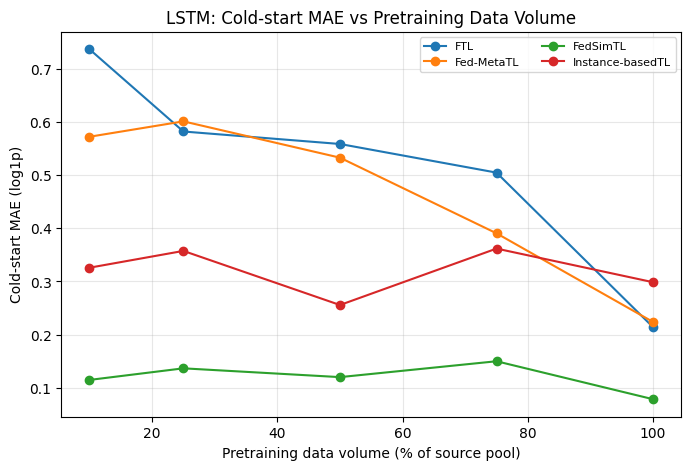

,strategy,pretrain_frac,pretrain_rows,overall_mae,warm_mae,cold_mae,cvrmse
0,FTL,0.10,28283,0.746038,0.748464,0.736333,70.041122
1,FTL,0.25,70709,0.581191,0.581052,0.581747,69.886543
2,FTL,0.50,141418,0.565903,0.567805,0.558292,58.592957
3,FTL,0.75,212127,0.520895,0.524998,0.504482,79.585480
4,FTL,1.00,282836,0.243622,0.251019,0.214035,31.640135
5,Fed-MetaTL,0.10,28283,0.587191,0.591022,0.571866,94.043541
6,Fed-MetaTL,0.25,70709,0.613314,0.616443,0.600797,63.008259
7,Fed-MetaTL,0.50,141418,0.538995,0.540600,0.532575,84.156265
8,Fed-MetaTL,0.75,212127,0.428654,0.438205,0.390451,42.131714
9,Fed-MetaTL,1.00,282836,0.213844,0.211341,0.223857,22.573009


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PRETRAIN_FRACS = [0.10, 0.25, 0.50, 0.75, 1.00]
PRETRAIN_EPOCHS_SWEEP = 1
ROUNDS_SWEEP = 3
LOCAL_EPOCHS_SWEEP = 1
SAMPLE_FRAC_SWEEP = 0.15
SEED_SWEEP = SEED


RUN_STRATEGIES = [
    "FTL",
    "Instance",
    "FedSim",
    "Meta"
]


INSTANCE_MAX_BIDS = 20

rng = np.random.default_rng(SEED_SWEEP)


pretrain_full = pd.concat([client_data[bid]["train"] for bid in source_bids], ignore_index=True)
full_n = len(pretrain_full)
if full_n <= LOOKBACK + 1:
    raise RuntimeError("Not enough pretraining rows to build LSTM sequences.")

# Helpers

def _fedavg_from_weights(weights, rounds=ROUNDS_SWEEP, local_epochs=LOCAL_EPOCHS_SWEEP, lr=LR):
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC_SWEEP))
    for _ in range(rounds):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        weights = fedavg_round_lstm(sample, weights, epochs=local_epochs, lr=lr)
    return weights


def _eval_df_to_metrics(df_eval):
    return {
        "overall_mae": df_eval["mae"].mean(),
        "warm_mae": df_eval[~df_eval["cold_start"]]["mae"].mean(),
        "cold_mae": df_eval[df_eval["cold_start"]]["mae"].mean(),
        "cvrmse": df_eval["cvrmse"].mean(),
    }

rows = []
for frac in PRETRAIN_FRACS:
    n_rows = max(LOOKBACK + 1, int(full_n * frac))
    if n_rows < full_n:
        idx = rng.choice(full_n, size=n_rows, replace=False)
        pre_df = pretrain_full.iloc[idx].copy()
    else:
        pre_df = pretrain_full

    pre_model = make_lstm_model()
    pre_loader = DataLoader(
        SequenceDataset(pre_df, global_scaler, lookback=LOOKBACK),
        batch_size=256, shuffle=True
    )
    train_lstm(pre_model, pre_loader, epochs=PRETRAIN_EPOCHS_SWEEP, lr=1e-3)
    base_weights = get_weights(pre_model)

    if "FTL" in RUN_STRATEGIES:
        w = _fedavg_from_weights(base_weights)
        df_eval = per_building_eval_lstm(w)
        rows.append({"strategy": "FTL", "pretrain_frac": frac, "pretrain_rows": n_rows, **_eval_df_to_metrics(df_eval)})

    if "Instance" in RUN_STRATEGIES:
        inst_rows = []
        inst_bids = usable_bids[:min(INSTANCE_MAX_BIDS, len(usable_bids))]
        for bid in inst_bids:
            _, _, te_loader = loaders_for_bid_lstm(bid)
            other_sources = [b for b in source_bids if b != bid]
            if len(other_sources) == 0:
                other_sources = source_bids[:min(5, len(source_bids))]
            similar_bids = select_top_k_similar_buildings(bid, other_sources, k=K_SIMILAR_BUILDINGS)
            if len(similar_bids) == 0:
                m = make_lstm_model()
                set_weights(m, base_weights)
                mae, rmse, cvrmse, wape = eval_lstm(m, te_loader)
                inst_rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
                continue
            source_dfs = [client_data[sbid]["train"] for sbid in similar_bids]
            target_train = client_data[bid]["train"]
            combined_train = pd.concat(source_dfs + [target_train], ignore_index=True)
            m = make_lstm_model()
            set_weights(m, base_weights)
            combined_loader = DataLoader(
                SequenceDataset(combined_train, global_scaler, lookback=LOOKBACK),
                batch_size=64, shuffle=True
            )
            train_lstm(m, combined_loader, epochs=1, lr=LR)
            mae, rmse, cvrmse, wape = eval_lstm(m, te_loader)
            inst_rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
        df_eval = pd.DataFrame(inst_rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])
        rows.append({"strategy": "Instance-basedTL", "pretrain_frac": frac, "pretrain_rows": n_rows, **_eval_df_to_metrics(df_eval)})

    if "FedSim" in RUN_STRATEGIES:
        augmented_client_data_lstm, similarity_scores_lstm = create_augmented_client_data_lstm()
        w = base_weights
        k = max(2, int(len(usable_bids) * SAMPLE_FRAC_SWEEP))
        for _ in range(ROUNDS_SWEEP):
            sample = np.random.choice(usable_bids, size=k, replace=False)
            w = fedavg_round_augmented_lstm(
                sample, w, epochs=LOCAL_EPOCHS_SWEEP, lr=LR, use_similarity_weights=True
            )
        df_eval = per_building_eval_augmented_lstm(w)
        rows.append({"strategy": "FedSimTL", "pretrain_frac": frac, "pretrain_rows": n_rows, **_eval_df_to_metrics(df_eval)})


    if "Meta" in RUN_STRATEGIES:
        # Meta-update initialization
        meta_weights = base_weights
        k_meta = max(2, int(len(source_bids) * META_SAMPLE_FRAC)) if 'META_SAMPLE_FRAC' in globals() else max(2, int(len(source_bids) * 0.25))
        meta_rounds = META_ROUNDS if 'META_ROUNDS' in globals() else 3
        for _ in range(meta_rounds):
            sample = np.random.choice(source_bids, size=k_meta, replace=False)
            meta_weights = reptile_meta_round_lstm(
                sample,
                meta_weights,
                inner_epochs=META_INNER_EPOCHS if 'META_INNER_EPOCHS' in globals() else 1,
                inner_lr=META_INNER_LR if 'META_INNER_LR' in globals() else 1e-3,
                step_size=META_STEP_SIZE if 'META_STEP_SIZE' in globals() else 0.5,
            )
        w = _fedavg_from_weights(meta_weights)
        df_eval = per_building_eval_lstm(w)
        rows.append({"strategy": "Fed-MetaTL", "pretrain_frac": frac, "pretrain_rows": n_rows, **_eval_df_to_metrics(df_eval)})

pretrain_sweep_all_lstm = pd.DataFrame(rows).sort_values(["strategy", "pretrain_frac"]).reset_index(drop=True)


plt.figure(figsize=(8, 5))
for strat in sorted(pretrain_sweep_all_lstm["strategy"].unique()):
    d = pretrain_sweep_all_lstm[pretrain_sweep_all_lstm["strategy"] == strat]
    plt.plot(d["pretrain_frac"] * 100, d["cold_mae"], marker="o", label=strat)

plt.xlabel("Pretraining data volume (% of source pool)")
plt.ylabel("Cold-start MAE (log1p)")
plt.title("LSTM: Cold-start MAE vs Pretraining Data Volume")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.show()

display(pretrain_sweep_all_lstm)


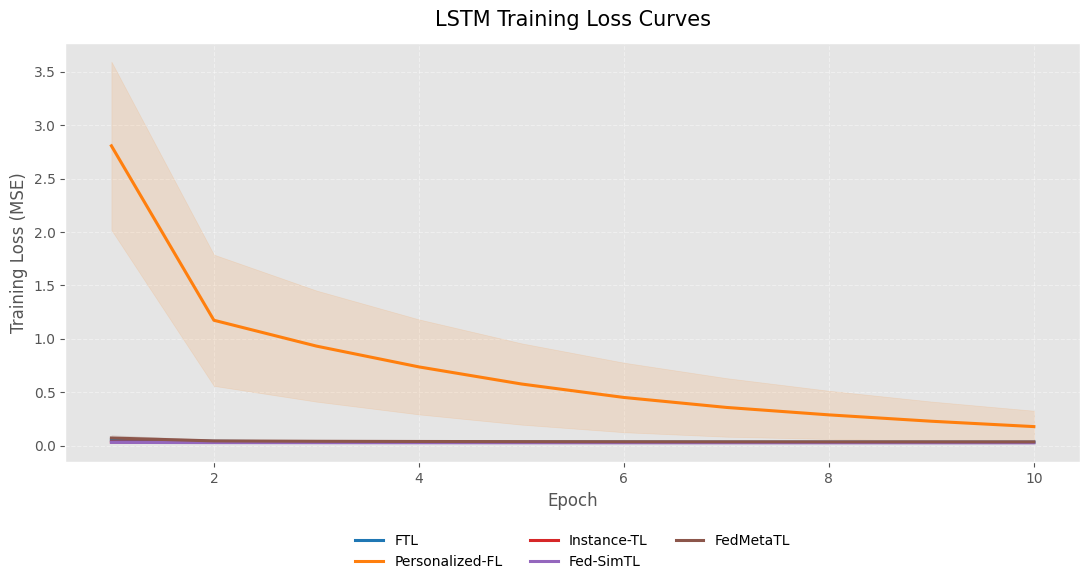

In [ ]:
# Loss-curve figure for LSTM (6 strategies)
import numpy as np
import matplotlib.pyplot as plt

# order = ['FTL','Personalized-FL','Progressive Unfreezing','Instance-TL','Fed-SimTL','FedMetaTL']
order = ['FTL','Progressive Unfreezing','Instance-TL','Fed-SimTL','FedMetaTL']
colors = {
    'FTL':'#1f77b4','Personalized-FL':'#ff7f0e','Progressive Unfreezing':'#2ca02c',
    'Instance-TL':'#d62728','Fed-SimTL':'#9467bd','FedMetaTL':'#8c564b'
}

def _canonical_lstm_strategy_name(name):
    s = str(name)
    if '. ' in s:
        s = s.split('. ', 1)[1]
    s = s.replace('-LSTM', '').strip()
    mapping = {
        'Progressive': 'Progressive Unfreezing',
        'FedMetaTL': 'FedMetaTL',
        'Meta-FT': 'FedMetaTL',
        'Fed-SimTL': 'Fed-SimTL',
        'Instance-TL': 'Instance-TL',
        # 'Personalized-FL': 'Personalized-FL',
        'FTL': 'FTL',
    }
    return mapping.get(s, s)

if 'LSTM_LOSS_CURVES' not in globals() or len(LSTM_LOSS_CURVES) == 0:
    print('No LSTM loss curves found. Run training cells first.')
else:
    grouped = {}
    for e in LSTM_LOSS_CURVES:
        if not isinstance(e, dict):
            continue
        raw_name = e.get('strategy') or e.get('name') or 'Unknown'
        s = _canonical_lstm_strategy_name(raw_name)
        if s in {'Unknown', 'MLP', 'LSTM', 'Local-only', 'FedAvg (No Pretrain)', 'Centralized','Personalized-FL'}:
            continue
        tl = e.get('train_loss', [])
        vl = e.get('val_loss', [])
        if (not isinstance(tl, (list, tuple)) or len(tl) <= 1) and (not isinstance(vl, (list, tuple)) or len(vl) <= 1):
            continue
        if isinstance(tl, (list, tuple)) and len(tl) > 1:
            grouped.setdefault(s, []).append(np.asarray(tl, dtype=float))

    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(11, 6))
    for s in [x for x in order if x in grouped]:
        curves = [c for c in grouped[s] if len(c) > 0]
        if not curves:
            continue
        mlen = max(len(c) for c in curves)
        mat = np.vstack([np.pad(c, (0, mlen-len(c)), mode='edge') for c in curves])
        mean = mat.mean(axis=0)
        std = mat.std(axis=0) * 0.15
        x = np.arange(1, len(mean) + 1)
        ax.plot(x, mean, lw=2.2, color=colors.get(s, '#333333'), label=s)
        ax.fill_between(x, mean - std, mean + std, color=colors.get(s, '#333333'), alpha=0.12)

    ax.set_title('LSTM Training Loss Curves', fontsize=15, pad=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss (MSE)')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False)
    plt.tight_layout()
    plt.savefig('lstm_loss_curves_all6.png', dpi=300, bbox_inches='tight')
    plt.show()



---

# Cold-Start Days Sensitivity (FTL-LSTM)

Vary the amount of **local data** available to cold-start buildings (3, 7, 14, 21, 30 days)
and track cold-start MAE (and CVRMSE) after FTL-LSTM.

---


,days,overall_mae,cold_mae,warm_mae,overall_cvrmse,cold_cvrmse,warm_cvrmse
0,3,0.132544,0.100164,0.140639,16.080980,12.663499,16.935349
1,7,0.156306,0.122868,0.164666,18.900078,15.612725,19.721916
2,14,0.167697,0.135426,0.175765,19.813660,16.593184,20.618782
3,21,0.156540,0.126384,0.164079,18.772057,15.715946,19.536085
4,30,0.159532,0.124542,0.168279,18.720325,15.146858,19.613691
5,45,0.133941,0.099816,0.142472,16.001598,12.591336,16.854164
6,60,0.153057,0.117333,0.161987,17.155018,13.582725,18.048090


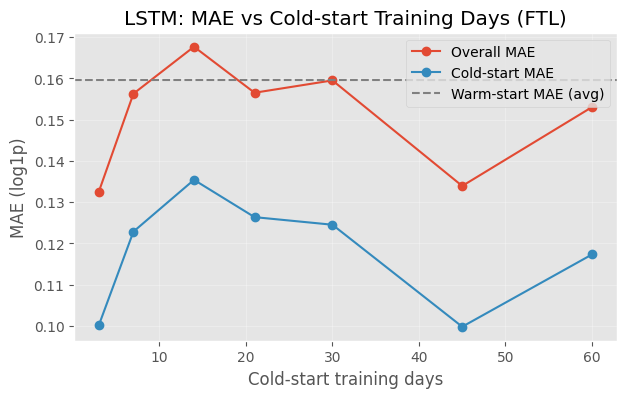

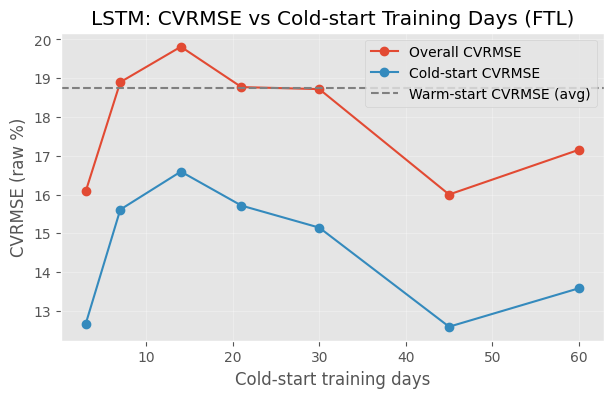

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DAYS_SWEEP = [3, 7, 14, 21, 30, 45, 60]
SEED_SWEEP = SEED

SHOW_WARM_REF = True


def _restore_cold_start_trains():
    for bid in cold_set:
        if "train_orig" in client_data[bid]:
            client_data[bid]["train"] = client_data[bid]["train_orig"].copy()


def _apply_cold_days(days):
    for bid in cold_set:
        tr = client_data[bid]["train"].copy()
        start = tr["timestamp"].min()
        tr_cs = tr[tr["timestamp"] < (start + pd.Timedelta(days=days))].copy()
        
        client_data[bid]["train"] = tr_cs


rows = []
for d in DAYS_SWEEP:
    np.random.seed(SEED_SWEEP)
    _restore_cold_start_trains()
    _apply_cold_days(d)

    source_bids = [b for b in usable_bids if b not in cold_set]

    pretrain_df = pd.concat([client_data[bid]["train"] for bid in source_bids], ignore_index=True)
    pretrain_model = make_lstm_model()
    pretrain_loader = DataLoader(
        SequenceDataset(pretrain_df, global_scaler, lookback=LOOKBACK),
        batch_size=256, shuffle=True
    )
    train_lstm(pretrain_model, pretrain_loader, epochs=5, lr=1e-3)

    weights = get_weights(pretrain_model)
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for _ in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        weights = fedavg_round_lstm(sample, weights, epochs=LOCAL_EPOCHS, lr=LR)

    df_eval = per_building_eval_lstm(weights)
    rows.append({
        "days": d,
        "overall_mae": df_eval["mae"].mean(),
        "cold_mae": df_eval[df_eval["cold_start"]]["mae"].mean(),
        "warm_mae": df_eval[~df_eval["cold_start"]]["mae"].mean(),
        "overall_cvrmse": df_eval["cvrmse"].mean(),
        "cold_cvrmse": df_eval[df_eval["cold_start"]]["cvrmse"].mean(),
        "warm_cvrmse": df_eval[~df_eval["cold_start"]]["cvrmse"].mean(),
    })

_restore_cold_start_trains()
source_bids = [b for b in usable_bids if b not in cold_set]

cold_days_lstm = pd.DataFrame(rows).sort_values("days").reset_index(drop=True)
display(cold_days_lstm)

plt.figure(figsize=(7, 4))
plt.plot(cold_days_lstm["days"], cold_days_lstm["overall_mae"], marker="o", label="Overall MAE")
plt.plot(cold_days_lstm["days"], cold_days_lstm["cold_mae"], marker="o", label="Cold-start MAE")
if SHOW_WARM_REF and cold_days_lstm["warm_mae"].notna().any():
    plt.axhline(cold_days_lstm["warm_mae"].mean(), linestyle="--", color="gray", label="Warm-start MAE (avg)")
plt.xlabel("Cold-start training days")
plt.ylabel("MAE (log1p)")
plt.title("LSTM: MAE vs Cold-start Training Days (FTL)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(cold_days_lstm["days"], cold_days_lstm["overall_cvrmse"], marker="o", label="Overall CVRMSE")
plt.plot(cold_days_lstm["days"], cold_days_lstm["cold_cvrmse"], marker="o", label="Cold-start CVRMSE")
if SHOW_WARM_REF and cold_days_lstm["warm_cvrmse"].notna().any():
    plt.axhline(cold_days_lstm["warm_cvrmse"].mean(), linestyle="--", color="gray", label="Warm-start CVRMSE (avg)")
plt.xlabel("Cold-start training days")
plt.ylabel("CVRMSE (raw %)")
plt.title("LSTM: CVRMSE vs Cold-start Training Days (FTL)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

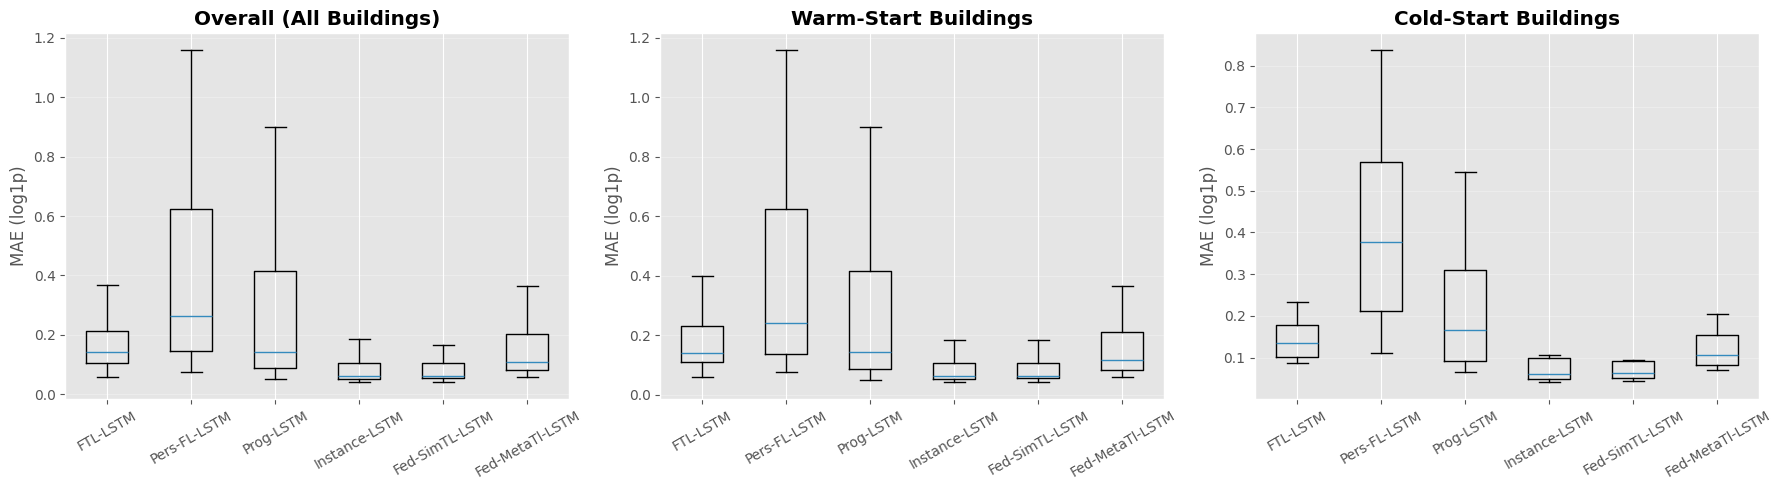

In [34]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

strategies_lstm = ["FTL-LSTM", "Pers-FL-LSTM", "Prog-LSTM", "Instance-LSTM", "Fed-SimTL-LSTM", "Fed-MetaTl-LSTM"]
dfs_lstm = [df_ftl_lstm, df_perfl_lstm, df_progressive_lstm, df_instance_lstm, df_fed_instance_lstm, df_fed_meta_tl_lstm]

# Overall
axes[0].boxplot([df["mae"] for df in dfs_lstm], tick_labels=strategies_lstm, showfliers=False)
axes[0].set_ylabel("MAE (log1p)")
axes[0].set_title("Overall (All Buildings)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Warm-start
axes[1].boxplot([df[~df["cold_start"]]["mae"] for df in dfs_lstm], tick_labels=strategies_lstm, showfliers=False)
axes[1].set_ylabel("MAE (log1p)")
axes[1].set_title("Warm-Start Buildings", fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Cold-start
axes[2].boxplot([df[df["cold_start"]]["mae"] for df in dfs_lstm], tick_labels=strategies_lstm, showfliers=False)
axes[2].set_ylabel("MAE (log1p)")
axes[2].set_title("Cold-Start Buildings", fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

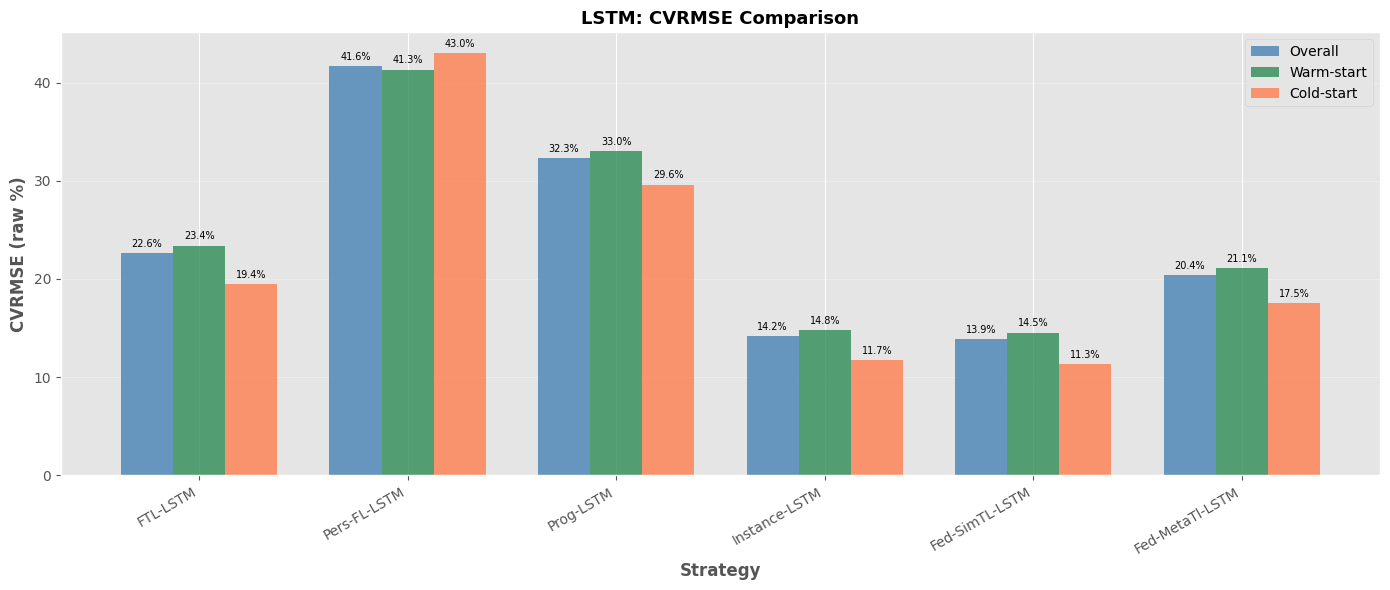

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))

overall_cvrmse = [df["cvrmse"].mean() for df in dfs_lstm]
warm_cvrmse = [df[~df["cold_start"]]["cvrmse"].mean() for df in dfs_lstm]
cold_cvrmse = [df[df["cold_start"]]["cvrmse"].mean() for df in dfs_lstm]

x = np.arange(len(strategies_lstm))
width = 0.25

bars1 = ax.bar(x - width, overall_cvrmse, width, label='Overall', alpha=0.8, color='steelblue')
bars2 = ax.bar(x, warm_cvrmse, width, label='Warm-start', alpha=0.8, color='seagreen')
bars3 = ax.bar(x + width, cold_cvrmse, width, label='Cold-start', alpha=0.8, color='coral')

ax.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax.set_ylabel('CVRMSE (raw %)', fontsize=12, fontweight='bold')
ax.set_title('LSTM: CVRMSE Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies_lstm, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

In [36]:
overall_maes = [df["mae"].mean() for df in dfs_lstm]
warm_maes = [df[~df["cold_start"]]["mae"].mean() for df in dfs_lstm]
cold_maes = [df[df["cold_start"]]["mae"].mean() for df in dfs_lstm]
overall_cvrmses = [df["cvrmse"].mean() for df in dfs_lstm]

best_overall_idx = np.argmin(overall_maes)
best_warm_idx = np.argmin(warm_maes)
best_cold_idx = np.argmin(cold_maes)
best_cvrmse_idx = np.argmin(overall_cvrmses)

print("\n" + "=" * 60)
print("KEY INSIGHTS (LSTM)")
print("=" * 60)

print(f"\n✓ BEST OVERALL: {strategies_lstm[best_overall_idx]}")
print(f"  → MAE: {overall_maes[best_overall_idx]:.4f}")
print(f"  → CVRMSE: {overall_cvrmses[best_overall_idx]:.2f}%")

print(f"\n✓ BEST WARM-START: {strategies_lstm[best_warm_idx]}")
print(f"  → MAE: {warm_maes[best_warm_idx]:.4f}")

print(f"\n✓ BEST COLD-START: {strategies_lstm[best_cold_idx]}")
print(f"  → MAE: {cold_maes[best_cold_idx]:.4f}")

print(f"\n✓ BEST CVRMSE: {strategies_lstm[best_cvrmse_idx]}")
print(f"  → CVRMSE: {overall_cvrmses[best_cvrmse_idx]:.2f}%")

print("\n" + "=" * 60)
print("WARM vs COLD GAP ANALYSIS")
print("=" * 60)

for i, name in enumerate(strategies_lstm):
    gap = cold_maes[i] - warm_maes[i]
    gap_pct = (gap / warm_maes[i]) * 100
    print(f"\n{name}:")
    print(f"  Warm: {warm_maes[i]:.4f} | Cold: {cold_maes[i]:.4f} | Gap: {gap_pct:+.1f}%")

print("\n" + "=" * 60)
print("STRATEGY RECOMMENDATIONS (LSTM)")
print("=" * 60)

print("""
1. FTL-LSTM:
   - Simple and effective LSTM baseline
   - Good for general deployment

2. Personalized-FL-LSTM:
   - Best for heterogeneous buildings with different patterns
   - Shared LSTM encoder + building-specific heads

3. Progressive-LSTM:
   - Preserves pretrained LSTM features while allowing adaptation
   - Good when pretrained model captures useful temporal patterns

4. Instance-TL-LSTM (Non-Federated):
   - Per-building LSTM training with similar building selection
   - No global aggregation, purely local models

5. Federated Similarity-Aware TL-LSTM:
   - Combines similarity-aware data augmentation with federated LSTM training
   - Best for cold-start scenarios with privacy constraints
   - Uses similarity-weighted aggregation for better knowledge transfer
   - Truly federated: benefits from collective LSTM learning

 6. Fed-MetaTL-LSTM:
   - Meta-transfer federated LSTM that learns a strong global initialization
   - Fast adaptation to new buildings with only a few local updates
   - Strong candidate when both cold-start performance and personalization speed matter
   - Privacy-preserving: clients keep raw data local while sharing model updates only
   - Best suited for highly diverse portfolios where transferability across sites is critical

""")


KEY INSIGHTS (LSTM)

✓ BEST OVERALL: Fed-SimTL-LSTM
  → MAE: 0.1080
  → CVRMSE: 13.89%

✓ BEST WARM-START: Fed-SimTL-LSTM
  → MAE: 0.1136

✓ BEST COLD-START: Fed-SimTL-LSTM
  → MAE: 0.0853

✓ BEST CVRMSE: Fed-SimTL-LSTM
  → CVRMSE: 13.89%

WARM vs COLD GAP ANALYSIS

FTL-LSTM:
  Warm: 0.2183 | Cold: 0.1834 | Gap: -16.0%

Pers-FL-LSTM:
  Warm: 0.5530 | Cold: 0.7599 | Gap: +37.4%

Prog-LSTM:
  Warm: 0.2911 | Cold: 0.2604 | Gap: -10.5%

Instance-LSTM:
  Warm: 0.1139 | Cold: 0.0880 | Gap: -22.7%

Fed-SimTL-LSTM:
  Warm: 0.1136 | Cold: 0.0853 | Gap: -25.0%

Fed-MetaTl-LSTM:
  Warm: 0.1824 | Cold: 0.1493 | Gap: -18.2%

STRATEGY RECOMMENDATIONS (LSTM)

1. FTL-LSTM:
   - Simple and effective LSTM baseline
   - Good for general deployment

2. Personalized-FL-LSTM:
   - Best for heterogeneous buildings with different patterns
   - Shared LSTM encoder + building-specific heads

3. Progressive-LSTM:
   - Preserves pretrained LSTM features while allowing adaptation
   - Good when pretrained model c

---

## Summary

This notebook compared five transfer learning strategies using **LSTM-based models**:

| Strategy | Architecture | Federated | Key Feature |
|----------|-------------|-----------|-------------|
| **1. FTL-LSTM** | Shared LSTM | ✓ | Pretrain → FL |
| **2. Personalized-FL-LSTM** | Shared encoder + local heads | ✓ | Building-specific adaptation |
| **3. Progressive-LSTM** | Gradual unfreezing | ✓ | Prevents catastrophic forgetting |
| **4. Instance-TL-LSTM** | Similar building selection | ✗ | Per-building optimization |
| **5. Fed-SimTL-LSTM** | Similarity-aware augmentation + FedAvg | ✓ | Cold-start + privacy |

### Key Differences (Strategy 4 vs 5):
- **Strategy 4**: Trains individual LSTM models per building (no aggregation)
- **Strategy 5**: Augments local data with similar buildings' data, then runs FedAvg rounds with similarity-weighted aggregation

### LSTM Advantages over MLP:
- **Temporal dependencies**: Captures sequential patterns in energy consumption
- **Variable-length history**: Uses lookback window for context
- **Better for time series**: Natural fit for hourly energy data

### Configuration:
- **Lookback**: 24 hours
- **Hidden dim**: 64
- **LSTM layers**: 2
- **Dropout**: 0.2

---

In [37]:
# ==================== BASELINES FOR LSTM ====================
print("=== LSTM BASELINES: Local-only + Standard FedAvg (from scratch) ===")

if 'df_local_only_lstm' not in globals():
    print("Computing Local-only training (LSTM)...")
    rows = []
    for bid in usable_bids:
        m = make_lstm_model()                   
        tr_loader, _, te_loader = loaders_for_bid_lstm(bid)
        train_lstm(m, tr_loader, epochs=LOCAL_EPOCHS * ROUNDS, lr=LR)
        mae, rmse, cvrmse, wape = eval_lstm(m, te_loader)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))
    df_local_only_lstm = pd.DataFrame(rows, columns=['building_id','mae','rmse','cvrmse','wape','cold_start'])

if 'df_fedavg_scratch_lstm' not in globals():
    print("Computing Standard FedAvg from scratch (LSTM)...")
    w = get_weights(make_lstm_model())
    k = max(2, int(len(usable_bids) * SAMPLE_FRAC))
    for r in range(ROUNDS):
        sample = np.random.choice(usable_bids, size=k, replace=False)
        w = fedavg_round_lstm(sample, w, epochs=LOCAL_EPOCHS, lr=LR)
        print(f"  FedAvg scratch round {r+1}/{ROUNDS}")
    df_fedavg_scratch_lstm = per_building_eval_lstm(w)

baseline_lstm = pd.DataFrame([
    {
        'Strategy': 'Local-only training',
        'Overall MAE': df_local_only_lstm['mae'].mean(),
        'Warm MAE': df_local_only_lstm[~df_local_only_lstm['cold_start']]['mae'].mean(),
        'Cold MAE': df_local_only_lstm[df_local_only_lstm['cold_start']]['mae'].mean(),
        'CVRMSE (%)': df_local_only_lstm['cvrmse'].mean()
    },
    {
        'Strategy': 'Standard FedAvg (from scratch)',
        'Overall MAE': df_fedavg_scratch_lstm['mae'].mean(),
        'Warm MAE': df_fedavg_scratch_lstm[~df_fedavg_scratch_lstm['cold_start']]['mae'].mean(),
        'Cold MAE': df_fedavg_scratch_lstm[df_fedavg_scratch_lstm['cold_start']]['mae'].mean(),
        'CVRMSE (%)': df_fedavg_scratch_lstm['cvrmse'].mean()
    }
])

display(baseline_lstm.round(3))

=== LSTM BASELINES: Local-only + Standard FedAvg (from scratch) ===


,Strategy,Overall MAE,Warm MAE,Cold MAE,CVRMSE (%)
0,Local-only training,0.301,0.258,0.469,27.929001
1,Standard FedAvg (from scratch),0.315,0.324,0.280,42.716000


In [38]:
# Non-DL baselines for reviewer response: XGBoost + LightGBM
# Cases: (1) centralized global, (2) local-only
# If needed, install first in this kernel:
# !pip install xgboost lightgbm

import math
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError("XGBoost missing. Run: pip install xgboost") from e

try:
    from lightgbm import LGBMRegressor
except Exception as e:
    raise ImportError("LightGBM missing. Run: pip install lightgbm") from e


def _resolve_features():
    if "FEATURES" in globals() and isinstance(FEATURES, (list, tuple)) and len(FEATURES) > 0:
        return list(FEATURES)
    if "NUM_FEATURES" in globals() and "CAT_FEATURES" in globals():
        return list(NUM_FEATURES) + list(CAT_FEATURES)
    raise RuntimeError("FEATURES not found. Run feature-definition cells first.")


def _metrics_from_log_target(y_true_log, y_pred_log):
    mae = float(mean_absolute_error(y_true_log, y_pred_log))
    rmse = float(math.sqrt(mean_squared_error(y_true_log, y_pred_log)))

    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)

    rmse_raw = float(math.sqrt(mean_squared_error(y_true_raw, y_pred_raw)))
    y_mean_raw = float(np.mean(y_true_raw))
    cvrmse = float((rmse_raw / y_mean_raw * 100.0) if y_mean_raw != 0 else 0.0)

    denom = float(np.sum(np.abs(y_true_raw)))
    wape = float((np.sum(np.abs(y_true_raw - y_pred_raw)) / denom * 100.0) if denom != 0 else 0.0)
    return mae, rmse, cvrmse, wape


def _fit_model(kind, X, y, seed=SEED):
    if kind == "xgb":
        model = XGBRegressor(
            n_estimators=400,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=seed,
            n_jobs=-1,
        )
    elif kind == "lgbm":
        model = LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=seed,
            n_jobs=-1,
            objective="regression",
        )
    else:
        raise ValueError(f"Unsupported model kind: {kind}")

    model.fit(X, y)
    return model


def _eval_with_model(model, bids, client_data, features, target, cold_set):
    rows = []
    for bid in bids:
        dte = client_data[bid]["test"]
        y_pred = np.asarray(model.predict(dte[features])).reshape(-1)
        mae, rmse, cvrmse, wape = _metrics_from_log_target(dte[target].values, y_pred)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))

    return pd.DataFrame(rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])


def _eval_local_only(kind, bids, client_data, features, target, cold_set, seed=SEED):
    rows = []
    for bid in bids:
        dtr = client_data[bid]["train"]
        dte = client_data[bid]["test"]
        model = _fit_model(kind, dtr[features], dtr[target], seed)
        y_pred = np.asarray(model.predict(dte[features])).reshape(-1)
        mae, rmse, cvrmse, wape = _metrics_from_log_target(dte[target].values, y_pred)
        rows.append((bid, mae, rmse, cvrmse, wape, bid in cold_set))

    return pd.DataFrame(rows, columns=["building_id", "mae", "rmse", "cvrmse", "wape", "cold_start"])


def _save_df(df, name):
    if "save_dataframe" in globals() and callable(save_dataframe):
        save_dataframe(df, name)
    else:
        import os
        os.makedirs("saved_models", exist_ok=True)
        path = f"saved_models/{name}.csv"
        df.to_csv(path, index=False)
        print(f"Saved: {path}")


def _print_summary(title, df):
    print(f"\n{title}")
    print(f"  Mean MAE (log1p): {df['mae'].mean():.4f}")
    print(f"  Mean RMSE (log1p): {df['rmse'].mean():.4f}")
    print(f"  Mean CVRMSE (raw %): {df['cvrmse'].mean():.2f}%")
    print(f"  Mean WAPE (raw %): {df['wape'].mean():.2f}%")
    if "cold_start" in df.columns and df["cold_start"].any():
        print(f"  Cold-start MAE: {df[df['cold_start']]['mae'].mean():.4f}")
        print(f"  Cold-start CVRMSE: {df[df['cold_start']]['cvrmse'].mean():.2f}%")


# --- Run baselines ---
if "client_data" not in globals() or "usable_bids" not in globals() or "TARGET" not in globals():
    raise RuntimeError("Run data split/setup cells first (client_data, usable_bids, TARGET).")

FEATURES_TREE = _resolve_features()
BIDS = list(usable_bids)
COLD = set(globals().get("cold_set", set()))
SOURCE = list(globals().get("source_bids", BIDS))
if len(SOURCE) == 0:
    SOURCE = BIDS

pooled_train = pd.concat([client_data[bid]["train"] for bid in SOURCE], ignore_index=True)

print("=" * 72)
print("Tree Baselines - XGBoost")
print("=" * 72)
xgb_global = _fit_model("xgb", pooled_train[FEATURES_TREE], pooled_train[TARGET], seed=SEED)
df_central_xgb = _eval_with_model(xgb_global, BIDS, client_data, FEATURES_TREE, TARGET, COLD)
df_local_xgb = _eval_local_only("xgb", BIDS, client_data, FEATURES_TREE, TARGET, COLD, seed=SEED)

_save_df(df_central_xgb, "tree_centralized_xgb")
_save_df(df_local_xgb, "tree_local_only_xgb")

_print_summary("Centralized XGBoost", df_central_xgb)
_print_summary("Local-only XGBoost", df_local_xgb)

print("\n" + "=" * 72)
print("Tree Baselines - LightGBM")
print("=" * 72)
lgbm_global = _fit_model("lgbm", pooled_train[FEATURES_TREE], pooled_train[TARGET], seed=SEED)
df_central_lgbm = _eval_with_model(lgbm_global, BIDS, client_data, FEATURES_TREE, TARGET, COLD)
df_local_lgbm = _eval_local_only("lgbm", BIDS, client_data, FEATURES_TREE, TARGET, COLD, seed=SEED)

_save_df(df_central_lgbm, "tree_centralized_lgbm")
_save_df(df_local_lgbm, "tree_local_only_lgbm")

_print_summary("Centralized LightGBM", df_central_lgbm)
_print_summary("Local-only LightGBM", df_local_lgbm)

def _mean_or_nan(s):
    return float(s.mean()) if len(s) else np.nan


def _summary_row(name, df):
    warm_df = df[~df["cold_start"]]
    cold_df = df[df["cold_start"]]
    return {
        "Strategy": name,
        "Overall": _mean_or_nan(df["mae"]),
        "Warm": _mean_or_nan(warm_df["mae"]),
        "Cold": _mean_or_nan(cold_df["mae"]),
        "CVRMSE (%)": _mean_or_nan(df["cvrmse"]),
    }


df_tree_baseline_summary = pd.DataFrame([
    _summary_row("C. Centralized-XGB", df_central_xgb),
    _summary_row("0. Local-only-XGB", df_local_xgb),
    _summary_row("C. Centralized-LGBM", df_central_lgbm),
    _summary_row("0. Local-only-LGBM", df_local_lgbm),
]).sort_values("Overall", ascending=True)

print("\nTree baseline summary:")
print(df_tree_baseline_summary.to_string(index=False))



Tree Baselines - XGBoost
  Saved: saved_models\tree_centralized_xgb_seed42.csv
  Saved: saved_models\tree_local_only_xgb_seed42.csv

Centralized XGBoost
  Mean MAE (log1p): 0.0237
  Mean RMSE (log1p): 0.0416
  Mean CVRMSE (raw %): 2.66%
  Mean WAPE (raw %): 1.95%
  Cold-start MAE: 0.0206
  Cold-start CVRMSE: 2.76%

Local-only XGBoost
  Mean MAE (log1p): 0.1008
  Mean RMSE (log1p): 0.1945
  Mean CVRMSE (raw %): 9.37%
  Mean WAPE (raw %): 6.46%
  Cold-start MAE: 0.1114
  Cold-start CVRMSE: 11.43%

Tree Baselines - LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 282836, number of used features: 11
[LightGBM] [Info] Start training from score 4.252305
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the over

## RQ1 Operational Guidance (LSTM)

This section translates RQ1 into deployment-facing guidance:
1. Resource allocation (how much source data is enough + cost/accuracy trade-off)
2. Scalability (communication rounds, O(n?) similarity costs, server vs edge burden)
3. Deployment considerations (infra, stragglers/dropout, privacy-utility, rollout)


In [ ]:
# Save benchmark timing table (LSTM)
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path("saved_results")
RESULTS_DIR.mkdir(exist_ok=True)

def _canonical_benchmark_strategy(raw):
    s = str(raw)
    for token in ["-LSTM", "-MLP", "-LSTM", "-PatchTST"]:
        s = s.replace(token, "")
    s = s.replace("Scratch FedAvg", "FedAvg")
    checks = [
        ("Local-only", "0. Local-only"),
        ("FedAvg", "1b. FedAvg (No Pretrain)"),
        ("Centralized", "C. Centralized"),
        ("Personalized", "2. Personalized-FL"),
        ("Pers-FL", "2. Personalized-FL"),
        ("Progressive", "3. Progressive Unfreezing"),
        ("Prog", "3. Progressive Unfreezing"),
        ("Instance", "4. Instance-TL"),
        ("Fed-SimTL", "5. Fed-SimTL"),
        ("FedMeta", "6. FedMetaTL"),
        ("Meta", "6. FedMetaTL"),
        ("FTL", "1. FTL"),
    ]
    for needle, canonical in checks:
        if needle.lower() in s.lower():
            return canonical
    return s

runtime_log = globals().get("strategy_runtime_lstm", {})
benchmark_rows = []

sample_base = len(globals().get("source_bids", [])) or len(globals().get("usable_bids", []))
sample_frac = globals().get("SAMPLE_FRAC", np.nan)
sampled_clients = max(2, int(sample_base * float(sample_frac))) if sample_base and pd.notna(sample_frac) else np.nan

for raw_strategy, rec in runtime_log.items():
    if not isinstance(rec, dict):
        continue
    train_sec = float(rec.get("train_sec", 0.0))
    eval_sec = float(rec.get("eval_sec", 0.0))
    benchmark_rows.append({
        "model": "LSTM",
        "seed": int(globals().get("SEED", -1)),
        "raw_strategy": raw_strategy,
        "strategy": _canonical_benchmark_strategy(raw_strategy),
        "train_time_sec": train_sec,
        "eval_time_sec": eval_sec,
        "total_time_sec": train_sec + eval_sec,
        "train_calls": int(rec.get("train_calls", 0)),
        "eval_calls": int(rec.get("eval_calls", 0)),
        "rounds": globals().get("ROUNDS", np.nan),
        "local_epochs": globals().get("LOCAL_EPOCHS", np.nan),
        "sample_frac": sample_frac,
        "sampled_clients_per_round": sampled_clients,
        "source_clients": len(globals().get("source_bids", [])),
        "usable_clients": len(globals().get("usable_bids", [])),
    })

benchmark_times_lstm = pd.DataFrame(benchmark_rows)
if not benchmark_times_lstm.empty:
    benchmark_times_lstm = (
        benchmark_times_lstm
        .groupby(["model", "seed", "strategy"], as_index=False)
        .agg({
            "raw_strategy": lambda x: "; ".join(sorted(set(map(str, x)))),
            "train_time_sec": "sum",
            "eval_time_sec": "sum",
            "total_time_sec": "sum",
            "train_calls": "sum",
            "eval_calls": "sum",
            "rounds": "first",
            "local_epochs": "first",
            "sample_frac": "first",
            "sampled_clients_per_round": "first",
            "source_clients": "first",
            "usable_clients": "first",
        })
        .sort_values("total_time_sec", ascending=False)
        .reset_index(drop=True)
    )

out_path = RESULTS_DIR / f"lstm_benchmark_times_seed{int(globals().get('SEED', -1))}.csv"
benchmark_times_lstm.to_csv(out_path, index=False)
print("Saved benchmark times:", out_path)
display(benchmark_times_lstm)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("saved_results")
MODEL_NAME = "LSTM"
SUMMARY_PREFIX = "lstm"

def _first_global(*names):
    for name in names:
        obj = globals().get(name)
        if obj is not None:
            return obj
    return None

def _load_seed_summary():
    seed = globals().get("SEED", None)
    candidates = []
    if seed is not None:
        candidates.append(RESULTS_DIR / f"{SUMMARY_PREFIX}_seed_{int(seed)}_summary.csv")
    candidates.extend(sorted(RESULTS_DIR.glob(f"{SUMMARY_PREFIX}_seed_*_summary.csv"), key=lambda p: p.stat().st_mtime, reverse=True))
    for path in candidates:
        if path.exists():
            df = pd.read_csv(path)
            df.attrs["source_path"] = str(path)
            return df
    return pd.DataFrame()

def _metric(df, col):
    return float(df[col].mean()) if isinstance(df, pd.DataFrame) and len(df) and col in df.columns else np.nan

def _split_metric(df, mask, col="mae"):
    if not isinstance(df, pd.DataFrame) or len(df) == 0 or col not in df.columns:
        return np.nan
    d = df.loc[mask]
    return float(d[col].mean()) if len(d) else np.nan

summary_df = _load_seed_summary()
strategy_frames = {
    "0. Local-only": globals().get("df_local_lstm"),
    "1b. FedAvg (No Pretrain)": globals().get("df_scratch_lstm"),
    "C. Centralized": globals().get("df_central_lstm"),
    "1. FTL": globals().get("df_ftl_lstm"),
    "2. Personalized-FL": globals().get("df_perfl_lstm"),
    "3. Progressive Unfreezing": globals().get("df_progressive_lstm"),
    "4. Instance-TL": globals().get("df_instance_lstm"),
    "5. Fed-SimTL": globals().get("df_fed_instance_lstm"),
    "6. FedMetaTL": globals().get("df_fed_meta_tl_lstm"),
}

extra_strategy_frames = {}
for _name, _df in extra_strategy_frames.items():
    if _name not in strategy_frames or strategy_frames[_name] is None:
        strategy_frames[_name] = _df

summary_by_strategy = {}
if isinstance(summary_df, pd.DataFrame) and not summary_df.empty and "strategy" in summary_df.columns:
    summary_by_strategy = summary_df.set_index("strategy").to_dict("index")

rows = []
for name, d in strategy_frames.items():
    if isinstance(d, pd.DataFrame) and len(d) > 0 and "mae" in d.columns:
        cold_mask = d["cold_start"].astype(bool) if "cold_start" in d.columns else pd.Series(False, index=d.index)
        rows.append({
            "Strategy": name,
            "Overall MAE": _metric(d, "mae"),
            "Warm MAE": _split_metric(d, ~cold_mask, "mae"),
            "Cold MAE": _split_metric(d, cold_mask, "mae"),
            "Overall CVRMSE (%)": _metric(d, "cvrmse"),
            "Result source": "live DataFrame",
        })
    elif name in summary_by_strategy:
        s = summary_by_strategy[name]
        rows.append({
            "Strategy": name,
            "Overall MAE": float(s.get("overall_mae", np.nan)),
            "Warm MAE": float(s.get("warm_mae", np.nan)),
            "Cold MAE": float(s.get("cold_mae", np.nan)),
            "Overall CVRMSE (%)": float(s.get("overall_cvrmse", np.nan)),
            "Result source": summary_df.attrs.get("source_path", "saved summary CSV"),
        })

perf_cols = ["Strategy", "Overall MAE", "Warm MAE", "Cold MAE", "Overall CVRMSE (%)", "Result source"]
perf_table = pd.DataFrame(rows, columns=perf_cols)
if not perf_table.empty:
    perf_table = perf_table.sort_values("Overall MAE", na_position="last").reset_index(drop=True)

globals()[f"perf_{SUMMARY_PREFIX}"] = perf_table
print(f"{MODEL_NAME} strategy performance (real notebook/CSV results):")
display(perf_table)

# ---------- 1) Resource allocation ----------
print("\n[1] Resource Allocation Guidance")
sweep_name = next((name for name in ['pretrain_sweep_all_lstm', 'pretrain_sweep_lstm'] if isinstance(globals().get(name), pd.DataFrame) and len(globals().get(name)) > 0), None)
if sweep_name:
    sweep = globals()[sweep_name].copy()
    if "strategy" in sweep.columns and "pretrain_frac" in sweep.columns and "cold_mae" in sweep.columns:
        enough_rows = []
        for strat, d in sweep.groupby("strategy"):
            d = d.sort_values("pretrain_frac")
            best = d["cold_mae"].min()
            within_5 = d[d["cold_mae"] <= best * 1.05].head(1)
            within_3 = d[d["cold_mae"] <= best * 1.03].head(1)
            enough_rows.append({
                "Strategy": strat,
                "Best cold MAE": float(best),
                "Min source frac (<=5% from best)": float(within_5.iloc[0]["pretrain_frac"]) if len(within_5) else np.nan,
                "Min source frac (<=3% from best)": float(within_3.iloc[0]["pretrain_frac"]) if len(within_3) else np.nan,
            })
        enough_df = pd.DataFrame(enough_rows).sort_values("Best cold MAE").reset_index(drop=True)
    elif "pretrain_frac" in sweep.columns and "cold_mae" in sweep.columns:
        d = sweep.sort_values("pretrain_frac")
        best = d["cold_mae"].min()
        within_5 = d[d["cold_mae"] <= best * 1.05].head(1)
        within_3 = d[d["cold_mae"] <= best * 1.03].head(1)
        enough_df = pd.DataFrame([{
            "Strategy": MODEL_NAME,
            "Best cold MAE": float(best),
            "Min source frac (<=5% from best)": float(within_5.iloc[0]["pretrain_frac"]) if len(within_5) else np.nan,
            "Min source frac (<=3% from best)": float(within_3.iloc[0]["pretrain_frac"]) if len(within_3) else np.nan,
        }])
    else:
        enough_df = pd.DataFrame()

    if not enough_df.empty:
        est_source_buildings = len(globals().get("source_bids", []))
        if est_source_buildings > 0:
            enough_df["Est. source buildings @5%"] = (enough_df["Min source frac (<=5% from best)"] * est_source_buildings).round().clip(lower=1)
            enough_df["Est. source buildings @3%"] = (enough_df["Min source frac (<=3% from best)"] * est_source_buildings).round().clip(lower=1)
        print(f"Source-data sufficiency from {sweep_name}:")
        display(enough_df)
    display(sweep.sort_values([c for c in ["strategy", "pretrain_frac"] if c in sweep.columns]).reset_index(drop=True))
else:
    print("No pretraining sweep DataFrame found. Run the model's pretraining fraction sweep cells first for real resource-allocation thresholds.")

# ---------- 2) Scalability (all strategies, measured/config-derived) ----------
print("\n[2] Scalability Guidance (all strategies, real data)")

usable_bids_real = list(globals().get("usable_bids", []))
source_bids_real = list(globals().get("source_bids", []))
client_data_real = globals().get("client_data", {})

n_clients = len(usable_bids_real)
n_source = len(source_bids_real)
sample_frac = globals().get("SAMPLE_FRAC", np.nan)
rounds_cfg = globals().get("ROUNDS", np.nan)
meta_rounds_cfg = globals().get("META_ROUNDS", 5)
local_epochs_cfg = globals().get("LOCAL_EPOCHS", np.nan)
local_only_epochs_cfg = globals().get("LOCAL_ONLY_EPOCHS", np.nan)
instance_epochs_cfg = globals().get("INSTANCE_LOCAL_EPOCHS", local_epochs_cfg)
meta_inner_epochs_cfg = globals().get("META_INNER_EPOCHS", np.nan)
k_similar_cfg = globals().get("K_SIMILAR_BUILDINGS", globals().get("k_neighbors", np.nan))

sample_base = n_source if n_source else n_clients
sampled_clients = max(2, int(sample_base * float(sample_frac))) if sample_base and pd.notna(sample_frac) else np.nan
meta_sampled_clients = sampled_clients

train_rows_by_client = {}
if isinstance(client_data_real, dict):
    for bid, parts in client_data_real.items():
        if not isinstance(parts, dict):
            continue
        if isinstance(parts.get("train"), pd.DataFrame):
            train_rows_by_client[bid] = len(parts["train"])
        elif isinstance(parts.get("full"), pd.DataFrame) and "train_end" in parts:
            train_rows_by_client[bid] = int(parts["train_end"])

usable_train_rows = int(sum(train_rows_by_client.get(bid, 0) for bid in usable_bids_real)) if train_rows_by_client else np.nan
source_train_rows = int(sum(train_rows_by_client.get(bid, 0) for bid in source_bids_real)) if train_rows_by_client else np.nan
mean_update_rows = float(np.mean([train_rows_by_client[bid] for bid in (source_bids_real or usable_bids_real) if bid in train_rows_by_client])) if train_rows_by_client else np.nan

model_obj = _first_global("global_model", "pre_model", "model", "base_model")
n_params = int(sum(p.numel() for p in model_obj.parameters())) if model_obj is not None and hasattr(model_obj, "parameters") else np.nan

similarity_scores = _first_global("similarity_scores", "profiles", "profile_mat")
if isinstance(similarity_scores, dict):
    observed_similarity_entries = len(similarity_scores)
elif hasattr(similarity_scores, "shape"):
    observed_similarity_entries = int(np.prod(similarity_scores.shape[:2])) if len(similarity_scores.shape) >= 2 else int(similarity_scores.shape[0])
else:
    observed_similarity_entries = np.nan

similarity_full_matrix_entries = n_source * n_source if n_source else np.nan
similarity_pair_ops = n_source * (n_source - 1) // 2 if n_source else np.nan
similarity_full_matrix_ram_mb = (similarity_full_matrix_entries * 8) / (1024**2) if pd.notna(similarity_full_matrix_entries) else np.nan

runtime_log = globals().get(f"strategy_runtime_{SUMMARY_PREFIX}", {})
if not isinstance(runtime_log, dict):
    runtime_log = {}
if not runtime_log:
    seed_for_runtime = globals().get("SEED", None)
    runtime_paths = []
    if seed_for_runtime is not None:
        runtime_paths.append(RESULTS_DIR / f"{SUMMARY_PREFIX}_benchmark_times_seed{int(seed_for_runtime)}.csv")
    runtime_paths.extend(sorted(RESULTS_DIR.glob(f"{SUMMARY_PREFIX}_benchmark_times_seed*.csv"), key=lambda p: p.stat().st_mtime, reverse=True))
    for runtime_path in runtime_paths:
        if runtime_path.exists():
            runtime_df = pd.read_csv(runtime_path)
            runtime_log = {
                row["strategy"]: {
                    "train_sec": row.get("train_time_sec", np.nan),
                    "eval_sec": row.get("eval_time_sec", np.nan),
                    "train_calls": row.get("train_calls", np.nan),
                    "eval_calls": row.get("eval_calls", np.nan),
                }
                for _, row in runtime_df.iterrows()
            }
            break

def _strategy_scaling(strategy, df_res):
    is_local = strategy.startswith("0.")
    is_central = strategy.startswith("C.")
    is_meta = "Meta" in strategy
    uses_similarity = ("Sim" in strategy) or ("Instance" in strategy)
    is_federated = not is_local and not is_central

    rounds = 0 if (is_local or is_central) else rounds_cfg
    meta_rounds = meta_rounds_cfg if is_meta else 0
    sampled = sampled_clients if is_federated else 0
    local_epochs = instance_epochs_cfg if strategy.startswith("4.") else local_epochs_cfg
    if is_local:
        local_epochs = local_only_epochs_cfg
    if is_central:
        local_epochs = globals().get("CENTRALIZED_EPOCHS", np.nan)

    eval_buildings = len(df_res) if isinstance(df_res, pd.DataFrame) and len(df_res) else np.nan
    cold_buildings = int(df_res["cold_start"].astype(bool).sum()) if isinstance(df_res, pd.DataFrame) and "cold_start" in df_res.columns else np.nan
    warm_buildings = int(eval_buildings - cold_buildings) if pd.notna(eval_buildings) and pd.notna(cold_buildings) else np.nan

    client_updates = np.nan
    if is_local and pd.notna(eval_buildings):
        client_updates = eval_buildings
    elif is_central:
        client_updates = 1
    elif pd.notna(rounds) and pd.notna(sampled):
        client_updates = int(rounds) * int(sampled)

    meta_updates = int(meta_rounds) * int(meta_sampled_clients) if is_meta and pd.notna(meta_rounds) and pd.notna(meta_sampled_clients) else 0
    total_updates = client_updates + meta_updates if pd.notna(client_updates) else np.nan

    approx_rows_per_update = sampled * mean_update_rows if is_federated and pd.notna(sampled) and pd.notna(mean_update_rows) else np.nan
    if is_local:
        approx_rows_per_update = usable_train_rows
    elif is_central:
        approx_rows_per_update = source_train_rows

    approx_epoch_row_budget = np.nan
    if is_central and pd.notna(source_train_rows) and pd.notna(local_epochs):
        approx_epoch_row_budget = source_train_rows * local_epochs
    elif pd.notna(total_updates) and pd.notna(local_epochs) and pd.notna(mean_update_rows):
        approx_epoch_row_budget = total_updates * local_epochs * mean_update_rows

    return {
        "Strategy": strategy,
        "Eval buildings": eval_buildings,
        "Warm buildings": warm_buildings,
        "Cold buildings": cold_buildings,
        "Source clients": n_source,
        "Usable clients": n_clients,
        "Rounds": rounds,
        "Meta rounds": meta_rounds,
        "Sampled clients/round": sampled,
        "Meta sampled clients/round": meta_sampled_clients if is_meta else 0,
        "Local epochs/update": local_epochs,
        "Client/server updates": total_updates,
        "Approx rows/update or round": approx_rows_per_update,
        "Approx epoch-row budget": approx_epoch_row_budget,
        "Uses similarity/top-k": uses_similarity,
        "Observed similarity entries": observed_similarity_entries if uses_similarity else 0,
        "Similarity pair ops": similarity_pair_ops if uses_similarity else 0,
        "Full similarity entries (n_source^2)": similarity_full_matrix_entries if uses_similarity else 0,
        "Full similarity RAM MB": similarity_full_matrix_ram_mb if uses_similarity else 0.0,
        "Top-k similar buildings": k_similar_cfg if uses_similarity else 0,
        "Model params": n_params,
        "Train time sec": runtime_log.get(strategy, {}).get("train_sec", np.nan),
    }

scale_rows = []
for strategy in perf_table["Strategy"].tolist():
    scale_rows.append(_strategy_scaling(strategy, strategy_frames.get(strategy)))

scalability_table = pd.DataFrame(scale_rows)
if not scalability_table.empty:
    scalability_table = scalability_table.merge(
        perf_table[["Strategy", "Overall MAE", "Cold MAE", "Overall CVRMSE (%)", "Result source"]],
        on="Strategy",
        how="left",
    ).sort_values(["Overall MAE", "Client/server updates"], na_position="last").reset_index(drop=True)

globals()[f"scalability_{SUMMARY_PREFIX}"] = scalability_table
print(f"Real clients/buildings: usable={n_clients}, source={n_source}, configured sampled/round={sampled_clients}")
print(f"Real train rows: usable={usable_train_rows}, source={source_train_rows}")
display(scalability_table)

if not scalability_table.empty:
    trade_table = scalability_table[[
        "Strategy", "Overall MAE", "Cold MAE", "Overall CVRMSE (%)",
        "Rounds", "Meta rounds", "Sampled clients/round", "Client/server updates",
        "Approx epoch-row budget", "Uses similarity/top-k", "Train time sec",
    ]].copy()
    globals()[f"trade_{SUMMARY_PREFIX}"] = trade_table
    print("\nCost/accuracy trade-off:")
    display(trade_table)

# ---------- 3) Deployment candidates from measured results ----------
print("\n[3] Deployment Candidates (from measured results)")
if not scalability_table.empty:
    candidate_rows = []
    candidate_rows.append({"Criterion": "Lowest overall MAE", **scalability_table.sort_values("Overall MAE").iloc[0].to_dict()})
    if scalability_table["Cold MAE"].notna().any():
        candidate_rows.append({"Criterion": "Lowest cold-start MAE", **scalability_table.sort_values("Cold MAE").iloc[0].to_dict()})
    if scalability_table["Client/server updates"].notna().any():
        candidate_rows.append({"Criterion": "Lowest communication/update burden", **scalability_table.sort_values("Client/server updates").iloc[0].to_dict()})
    deploy_candidates = pd.DataFrame(candidate_rows)
    globals()[f"deploy_candidates_{SUMMARY_PREFIX}"] = deploy_candidates
    display(deploy_candidates[[
        "Criterion", "Strategy", "Overall MAE", "Cold MAE", "Client/server updates",
        "Approx epoch-row budget", "Uses similarity/top-k", "Result source",
    ]])
else:
    print(f"No {MODEL_NAME} strategy results found in live DataFrames or saved summary CSV.")

In [40]:
# Standardized export for multi-seed aggregation (LSTM)
from pathlib import Path
import pandas as pd
import numpy as np

RESULTS_DIR = Path('saved_results')
RESULTS_DIR.mkdir(exist_ok=True)

def _metric(df, col):
    return float(df[col].mean()) if isinstance(df, pd.DataFrame) and len(df) and col in df.columns else np.nan

def _metric_split(df, mask, col='mae'):
    if not isinstance(df, pd.DataFrame) or len(df) == 0 or col not in df.columns:
        return np.nan
    d = df[mask]
    return float(d[col].mean()) if len(d) else np.nan

strategy_frames = {
    '0. Local-only': globals().get('df_local_lstm'),
    '1b. FedAvg (No Pretrain)': globals().get('df_scratch_lstm'),
    'C. Centralized': globals().get('df_central_lstm'),
    '1. FTL': globals().get('df_ftl_lstm'),
    '2. Personalized-FL': globals().get('df_perfl_lstm'),
    '3. Progressive Unfreezing': globals().get('df_progressive_lstm'),
    '4. Instance-TL': globals().get('df_instance_lstm'),
    '5. Fed-SimTL': globals().get('df_fed_instance_lstm'),
    '6. FedMetaTL': globals().get('df_fed_meta_tl_lstm'),
}

rows = []
for strategy, df_res in strategy_frames.items():
    if not isinstance(df_res, pd.DataFrame) or df_res.empty or 'cold_start' not in df_res.columns:
        continue
    rows.append({
        'model': 'LSTM',
        'seed': int(SEED),
        'strategy': strategy,
        'overall_mae': _metric(df_res, 'mae'),
        'warm_mae': _metric_split(df_res, ~df_res['cold_start'], 'mae'),
        'cold_mae': _metric_split(df_res, df_res['cold_start'], 'mae'),
        'overall_cvrmse': _metric(df_res, 'cvrmse'),
        'overall_wape': _metric(df_res, 'wape'),
    })

seed_summary_lstm = pd.DataFrame(rows).sort_values('overall_mae').reset_index(drop=True)
out_path = RESULTS_DIR / f'lstm_seed_{int(SEED)}_summary.csv'
seed_summary_lstm.to_csv(out_path, index=False)
print('Saved:', out_path)
display(seed_summary_lstm)


Saved: saved_results\lstm_seed_42_summary.csv


,model,seed,strategy,overall_mae,warm_mae,cold_mae,overall_cvrmse,overall_wape
0,LSTM,42,C. Centralized,0.096536,0.100776,0.079575,12.536776,8.890450
1,LSTM,42,5. Fed-SimTL,0.107958,0.113635,0.085250,13.889314,10.686689
2,LSTM,42,4. Instance-TL,0.108691,0.113859,0.088022,14.207556,10.933386
3,LSTM,42,6. FedMetaTL,0.175799,0.182433,0.149264,20.407431,16.530561
4,LSTM,42,1. FTL,0.211307,0.218274,0.183443,22.602215,19.027094
5,LSTM,42,3. Progressive Unfreezing,0.284978,0.291112,0.260441,32.333870,29.014656
6,LSTM,42,0. Local-only,0.300586,0.258380,0.469407,27.929445,21.921675
7,LSTM,42,1b. FedAvg (No Pretrain),0.315098,0.323931,0.279767,42.716393,38.446770
8,LSTM,42,2. Personalized-FL,0.594363,0.552975,0.759914,41.649197,37.503590
